This notebook presents a detailed analysis of the individual dimensions of a 5-dimensional synthetic dataset. The goal is to visually understand how some of the transformations discussed in the paper **"Beyond Normal: On the evaluation of mutual information estimators"** impact each dimension of the data.

Additionally, several mutual information estimators from the same paper were tested on three different cases: untransformed data, Gaussian-transformed data, and t-student-transformed data. Mutual information estimation was performed on each individual dimension as well as jointly, even though these estimators are primarily designed for continuous data. The applied estimators were as follows:

- **Histogram-based estimator**
- **Canonical Correlation Analysis (CCA)**
- **Kraskov–Stögbauer–Grassberger (KSG) estimator:** 
    - For individual dimensions, the scikit-learn implementation was used due to its significantly faster performance compared to the BMI paper's implementation. However, for joint mutual information estimation, the paper's implementation was utilized since the scikit-learn version only estimates mutual information by dimensions.
- **Mutual Information Neural Estimator (MINE)**

The results demonstrate the correct application of the transformations to the data and confirm the theorem proposed in the paper, which argues that these transformations preserve the mutual information of the original data, both for individual dimensions and jointly. The differences between the estimates and the ground truth are mainly due to the different estimators and their methods for calculating mutual information.

In [5]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from typing import Dict, List
from scipy.stats import gaussian_kde
from joblib import Parallel, delayed

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../src/bmi/benchmark')))

from synthetic_tasks.synthetic import task_synthetic
from utils.utils_synthetic import plot_3d_figure

from synthetic_tasks.half_cube import transform_half_cube_task as half_cube
from synthetic_tasks.asinh import transform_asinh_task as asinh
from synthetic_tasks.normal_cdf import transform_normal_cdf_task as uniform_margins 

from synthetic_tasks.inverted_gaussian_cdf import transform_gaussian_cdf_task as gaussian_cdf
from synthetic_tasks.inverted_tstudent_cdf import transform_student_cdf_task as student_cdf

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../scripts/Beyond_Normal/benchmark')))
from estimators_benchmark import compare_EMI, compare_joint_EMI
from transformations_mi_benchmark import bench_mi_transformations, bench_joint_mi_transformations
from swissroll_embbeding import dim_augmented

In [6]:
def plot_dim_distribution(datasets: List[np.ndarray],
                          data_names: List[str] = None,
                          savefig: bool = False
                          ) -> None:
    """ 
    Plots the distribution of dimensions for multiple datasets in a grid of histograms.
    
    Args:
        datasets (List[np.ndarray]): A list of numpy arrays, where each array represents a dataset with rows as samples 
                                     and columns as dimensions. All arrays must have the same number of columns (dimensions).
        data_names (List[str], optional): A list of names for each dataset, used to label each row of histograms. Default is None.
        savefig (bool, optional): If True, saves the figure as a PDF file. Default is False.  
    
    """
    # Define the name of each column 
    dimension_names = [f"Dimension {i+1}" for i in range(datasets[0].shape[1])]

    dim_num = datasets[0].shape[1] # Number of dimensions
    num_datasets = len(datasets) # Number of datasets

    # Determines the common ranges for each dimension
    x_ranges = []
    for i in range(dim_num):
        min_val = min([data[:, i].min() for data in datasets])
        max_val = max([data[:, i].max() for data in datasets])
        x_ranges.append((min_val, max_val))

    fig, axes = plt.subplots(nrows=num_datasets, ncols=dim_num, figsize=(15, 4 * num_datasets))

    # Generates histograms
    for row, (data, name) in enumerate(zip(datasets, data_names)):
        for col in range(dim_num):
            axes[row, col].hist(data[:, col], edgecolor='k', alpha=0.7, bins=45, range=x_ranges[col])
        
            # Ensures that all charts in the same column have the same range on the x-axis
            axes[row, col].set_xlim(x_ranges[col])
            
            # Removes the titles from the plots
            axes[row, col].set_title("")
            axes[row, col].set_xlabel('')
            axes[row, col].set_ylabel('')

        # Add the name of the dataset on the left side of each row
        axes[row, 0].set_ylabel(name, rotation=0, size='large', labelpad=10, ha='right')

    # Add the name of each dimension at the top of each column
    for col, dim_name in enumerate(dimension_names):
        axes[0, col].set_title(dim_name, size='large')
    
    # Save the figure as a PDF if savefig is set to True
    if savefig:
       fig.savefig(fname="dims_distributions.pdf")
        
    plt.tight_layout()
    plt.show()


def plot_dim_density(datasets: List[np.ndarray],
                           data_names: List[str] = None,
                           savefig: bool = False
                           ) -> None:
    """ 
    Plots the density distribution of data points across multiple dimensions for several datasets.
    
    Args:
        datasets (List[np.ndarray]): A list of numpy arrays, where each array represents a dataset with rows as samples 
                                     and columns as dimensions. All arrays must have the same number of columns (dimensions).
        data_names (List[str], optional): A list of names for each dataset, used to label each row of histograms. Default is None.
        savefig (bool, optional): If True, saves the figure as a PDF file. Default is False.  
    
    """
    def calculate_kde(x, i):
        """Calculate the Kernel Density Estimate (KDE) for the i-th dimension."""
        xy = np.vstack([range(len(x)), x[:, i]])
        z = gaussian_kde(xy)(xy)
        return z

    # Define the name of each column 
    dimension_names = [f"Dimension {i+1}" for i in range(datasets[0].shape[1])]

    dim_num = datasets[0].shape[1] # Number of dimensions
    num_datasets = len(datasets) # Number of datasets
    
    # Determines the common ranges for each dimension
    x_ranges = []
    for i in range(dim_num):
        min_val = min([data[:, i].min() for data in datasets])
        max_val = max([data[:, i].max() for data in datasets])
        x_ranges.append((min_val, max_val))
    
    fig, axes = plt.subplots(nrows=num_datasets, ncols=dim_num, figsize=(15, 5 * num_datasets))

    # Calculates the KDE and generates the graphs
    for row, (data, name) in enumerate(zip(datasets, data_names)):
        # Calculates the KDE in parallel for each dimension of the current data
        z_list = Parallel(n_jobs=-1)(delayed(calculate_kde)(data, i) for i in range(dim_num))
        
        for col in range(dim_num):
            # Plots the data points with colors based on the KDE values
            axes[row, col].scatter(data[:, col], range(len(data)), c=z_list[col], cmap='viridis', s=20)
            axes[row, col].set_xlim(x_ranges[col])
            # Removes individual titles and labels
            axes[row, col].set_title("")
            axes[row, col].set_xlabel('')
            axes[row, col].set_ylabel('')
            
        # Add the name of the dataset on the left side of each row
        axes[row, 0].set_ylabel(name, rotation=0, size='large', labelpad=10, ha='right')

    # Add the name of each dimension at the top of each column
    for col, dim_name in enumerate(dimension_names):
        axes[0, col].set_title(dim_name, size='large')

    # Save the figure as a PDF if savefig is set to True
    if savefig:
       fig.savefig(fname="dims_density_distribution.pdf")
       
    plt.tight_layout()
    plt.show()

In [7]:
# Define a base probability array for the demonstration scenario.
base_demo_probabilities: np.ndarray = np.array(
    [
        [[0.4, 0.05], [0.3, 0.0], [0.2, 0.0], [0.05, 0.0]],  
        [[0.0, 0.2], [0.0, 0.3], [0.3, 0.0], [0.2, 0.0]],   
        [[0.0, 0.0], [0.0, 0.0], [0.0, 0.7], [0.3, 0.0]],   
    ]
)
# Create a dictionary to define the 2D scenario for the synthetic distribution
demo_2d_scenario: Dict[str, np.ndarray] = {
    # Probabilities for each symbol
    "sym_prob": np.array([0.2, 0.5, 0.3]),
    # Cell boundaries in the 2D space
    "cell_bound": np.array(
        [
            np.array([-0.5, 0.5, 1.5, 2.0, 3.5]),  
            np.array([1.0, 1.5, 2.5])
        ],
        dtype="object",
    ),
    # Cell probabilities copied from the base probabilities array
    "cell_prob": np.copy(a=base_demo_probabilities),
    }


# Initialize an empty numpy array to store the study scenario probabilities
study_scenario_probabilities: np.ndarray = np.empty(
    shape=base_demo_probabilities.shape[:-1] + (4,) + base_demo_probabilities.shape[-1:]
)

# Copy the base demo probabilities into different slices of the new array
study_scenario_probabilities[..., 0, :] = np.copy(a=base_demo_probabilities)
study_scenario_probabilities[..., 1, :] = np.copy(a=base_demo_probabilities)
study_scenario_probabilities[..., 2, :] = np.copy(a=base_demo_probabilities)
study_scenario_probabilities[..., 3, :] = np.copy(a=base_demo_probabilities)

# Modify specific slices to zero out certain probabilities
study_scenario_probabilities[0, :, 1, :] = 0.0
study_scenario_probabilities[1, :, 2, :] = 0.0
study_scenario_probabilities[2, :, 3, :] = 0.0

# Normalize the probabilities across certain dimensions
study_scenario_probabilities = study_scenario_probabilities / np.reshape(
    a=np.sum(a=study_scenario_probabilities, axis=(1, 2, 3)), newshape=(3,) + (1,) * 3
)

# Create a dictionary to define the scenario for the study distribution
study_scenario: Dict[str, np.ndarray] = {
    # Use the symbol probabilities from the demo 2D scenario
    "sym_prob": demo_2d_scenario["sym_prob"],

    # Define the cell boundaries for the study scenario
    "cell_bound": np.array(
        [
            demo_2d_scenario["cell_bound"][0],  
            np.array([-2.0, 2.0]),  
            np.array([-1.0, 0.0, 0.3, 1.0, 3.0]),  
            np.array([4.0, 4.5]),  
            demo_2d_scenario["cell_bound"][-1],  
        ],
        dtype="object",
    ),
    
    # Reshape the cell probabilities to add new axes for the scenario
    "cell_prob": study_scenario_probabilities[..., np.newaxis, :, np.newaxis, :],
}

## Base Case 5-dimensional

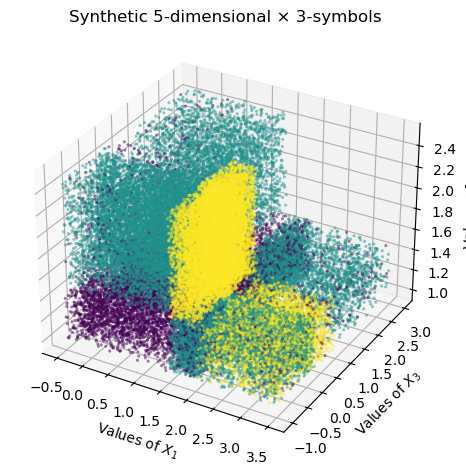

Joint mutual information: 1.181942440972768


In [11]:
# Number of samples  
n_samples = 50_000
# Seed for random number generator to ensure reproducibility
SEED = 1234

# Create a synthetic distribution object
synthetic_dist_study = task_synthetic(
   cell_boundaries=study_scenario['cell_bound'],
   symbol_probabilities=study_scenario['sym_prob'],
   cell_probabilities=study_scenario['cell_prob']
   )
    
# Sample 'n_samples' data points from the synthetic distribution 
x_sample, y_sample = synthetic_dist_study.sample(n_samples=n_samples, seed=SEED)

# Apply half-cube mapping
half_cube_map = half_cube(synthetic_dist_study)
half_cube_x_sample, half_cube_y_sample = half_cube_map.sample(n_samples=n_samples, seed=SEED)

# Apply asinh mapping
asinh_map = asinh(synthetic_dist_study)
asinh_x_sample, asinh_y_sample = asinh_map.sample(n_samples=n_samples, seed=SEED)

# Apply uniform margins transformation
uniform_margins_map = uniform_margins(synthetic_dist_study)
uniform_x_sample, uniform_y_sample = uniform_margins_map.sample(n_samples=n_samples, seed=SEED)


# Plot the 3D figure of the sampled data points
plot_3d_figure(
   X=x_sample,
   y=y_sample, 
   cell_boundaries=study_scenario['cell_bound'], 
   title=synthetic_dist_study.name,
   savefig=False,
   savedata=False
   )

print(f'Joint mutual information: {synthetic_dist_study.mutual_information}')

 22%|███████████▋                                        | 2250/10000 [01:54<06:35, 19.60step/s, test=-0.00, train=0.00]


 22%|███████████▋                                        | 2250/10000 [01:02<03:33, 36.23step/s, test=-0.00, train=0.00]


 15%|███████▉                                             | 1500/10000 [00:41<03:53, 36.42step/s, test=0.11, train=0.07]


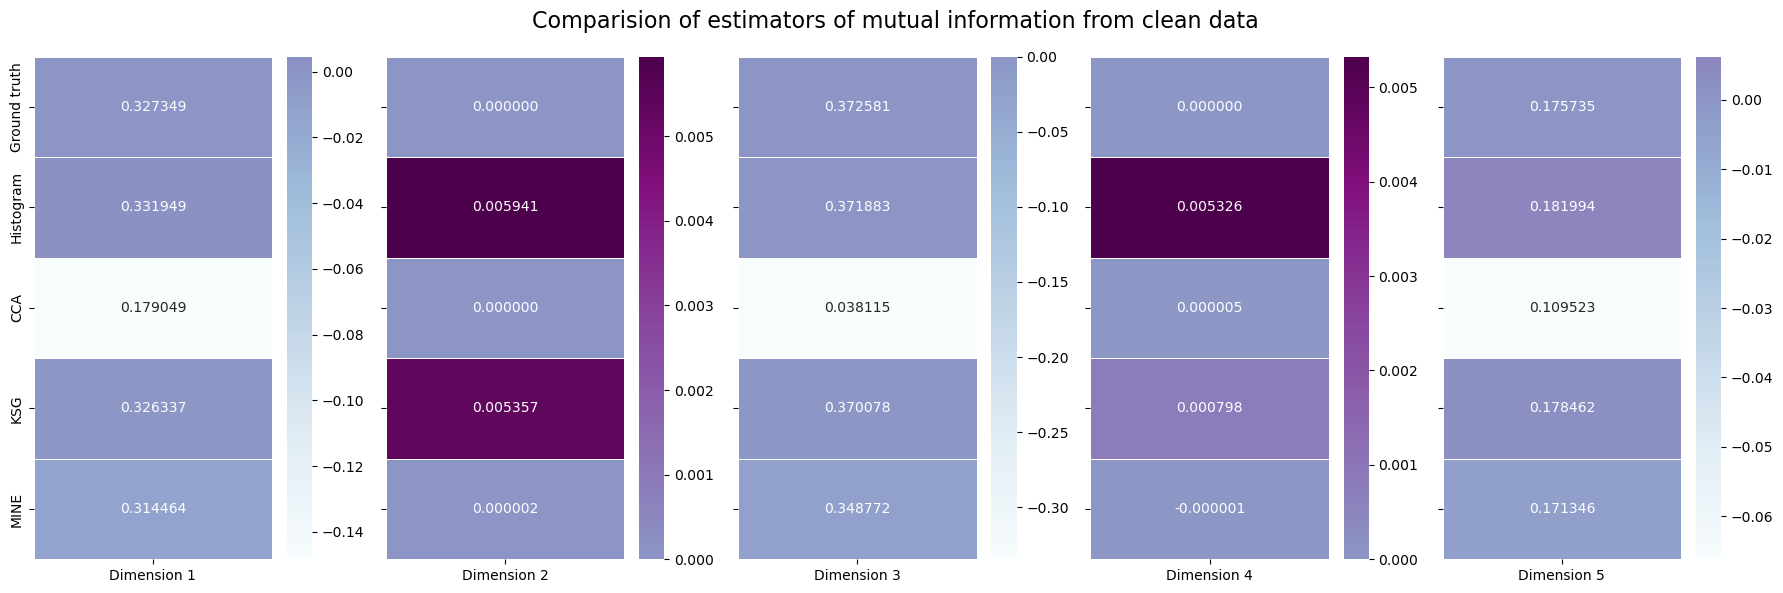

CPU times: total: 1min 42s
Wall time: 8min 36s


In [4]:
%%time
# Estimate mutual information of each dimension
ground_truth = [synthetic_dist_study.sampler.get_metadata()[f"mi_{i}"] for i in range(1, x_sample.shape[1]+1)]
compare_EMI(X=x_sample, y=y_sample, ground_truth=ground_truth, title=True)

 22%|███████████▋                                        | 2250/10000 [01:01<03:33, 36.38step/s, test=-0.00, train=0.00]


 22%|███████████▉                                         | 2250/10000 [01:02<03:34, 36.16step/s, test=0.21, train=0.21]


 22%|███████████▋                                        | 2250/10000 [01:02<03:34, 36.16step/s, test=-0.00, train=0.00]


 15%|███████▉                                             | 1500/10000 [00:41<03:53, 36.42step/s, test=0.11, train=0.05]


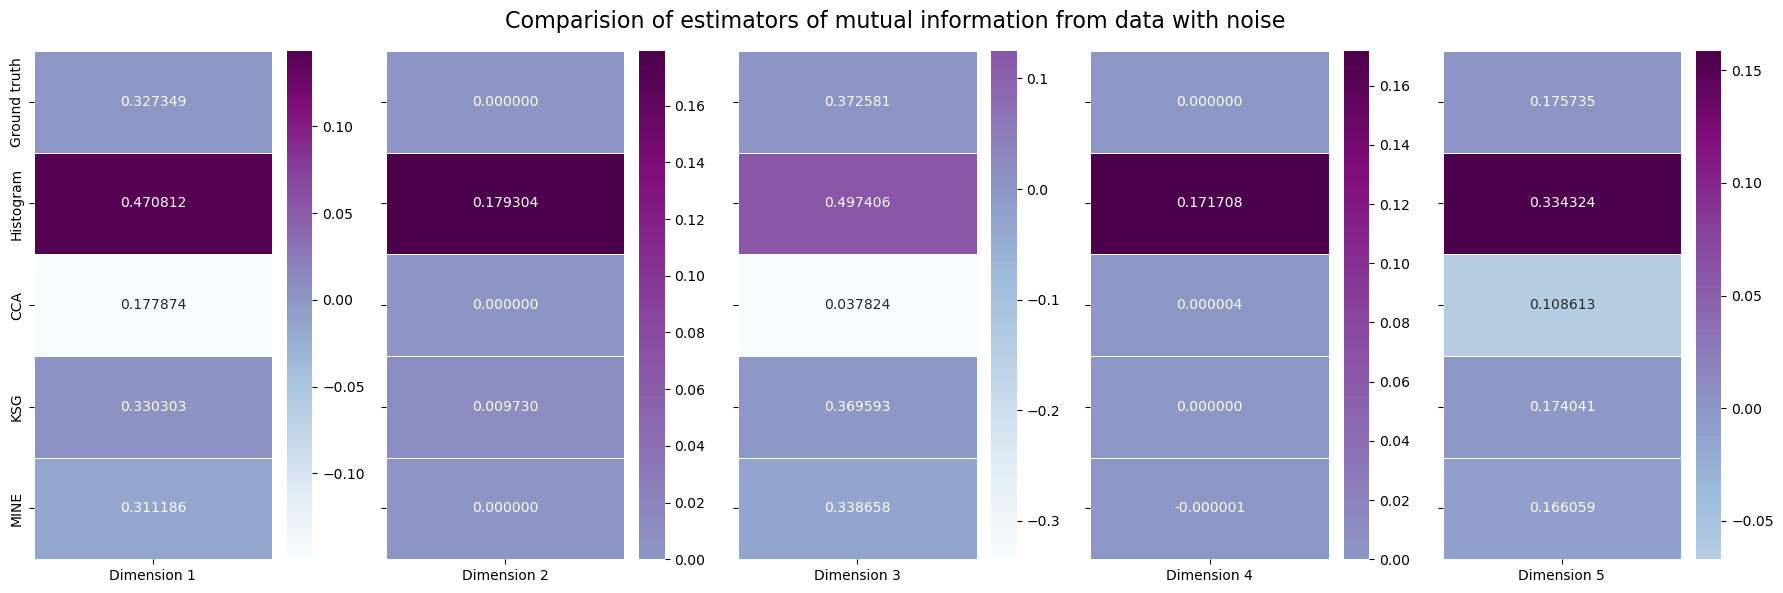

CPU times: total: 32.2 s
Wall time: 4min 37s


In [5]:
%%time
ground_truth = [synthetic_dist_study.sampler.get_metadata()[f"mi_{i}"] for i in range(1, x_sample.shape[1]+1)]
compare_EMI(X=x_sample, y=y_sample, ground_truth=ground_truth, add_noise=True, title=True)

 25%|█████████████▎                                       | 2500/10000 [01:42<05:07, 24.40step/s, test=0.67, train=0.73]


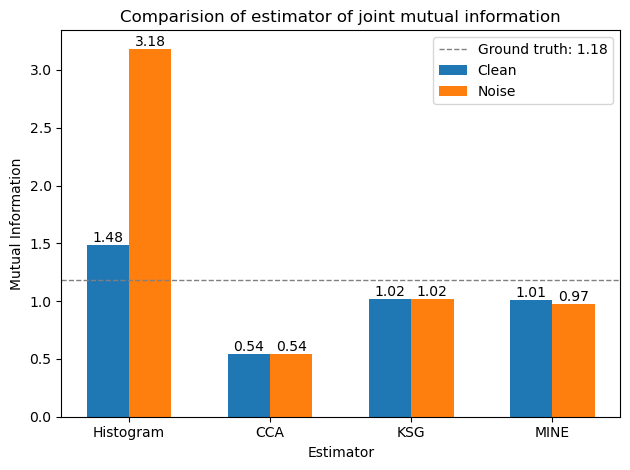

CPU times: total: 10min 45s
Wall time: 29min 27s


In [6]:
%%time
ground_truth = round(synthetic_dist_study.mutual_information, 2)
compare_joint_EMI(X=x_sample, y=y_sample, ground_truth=ground_truth, title=True)

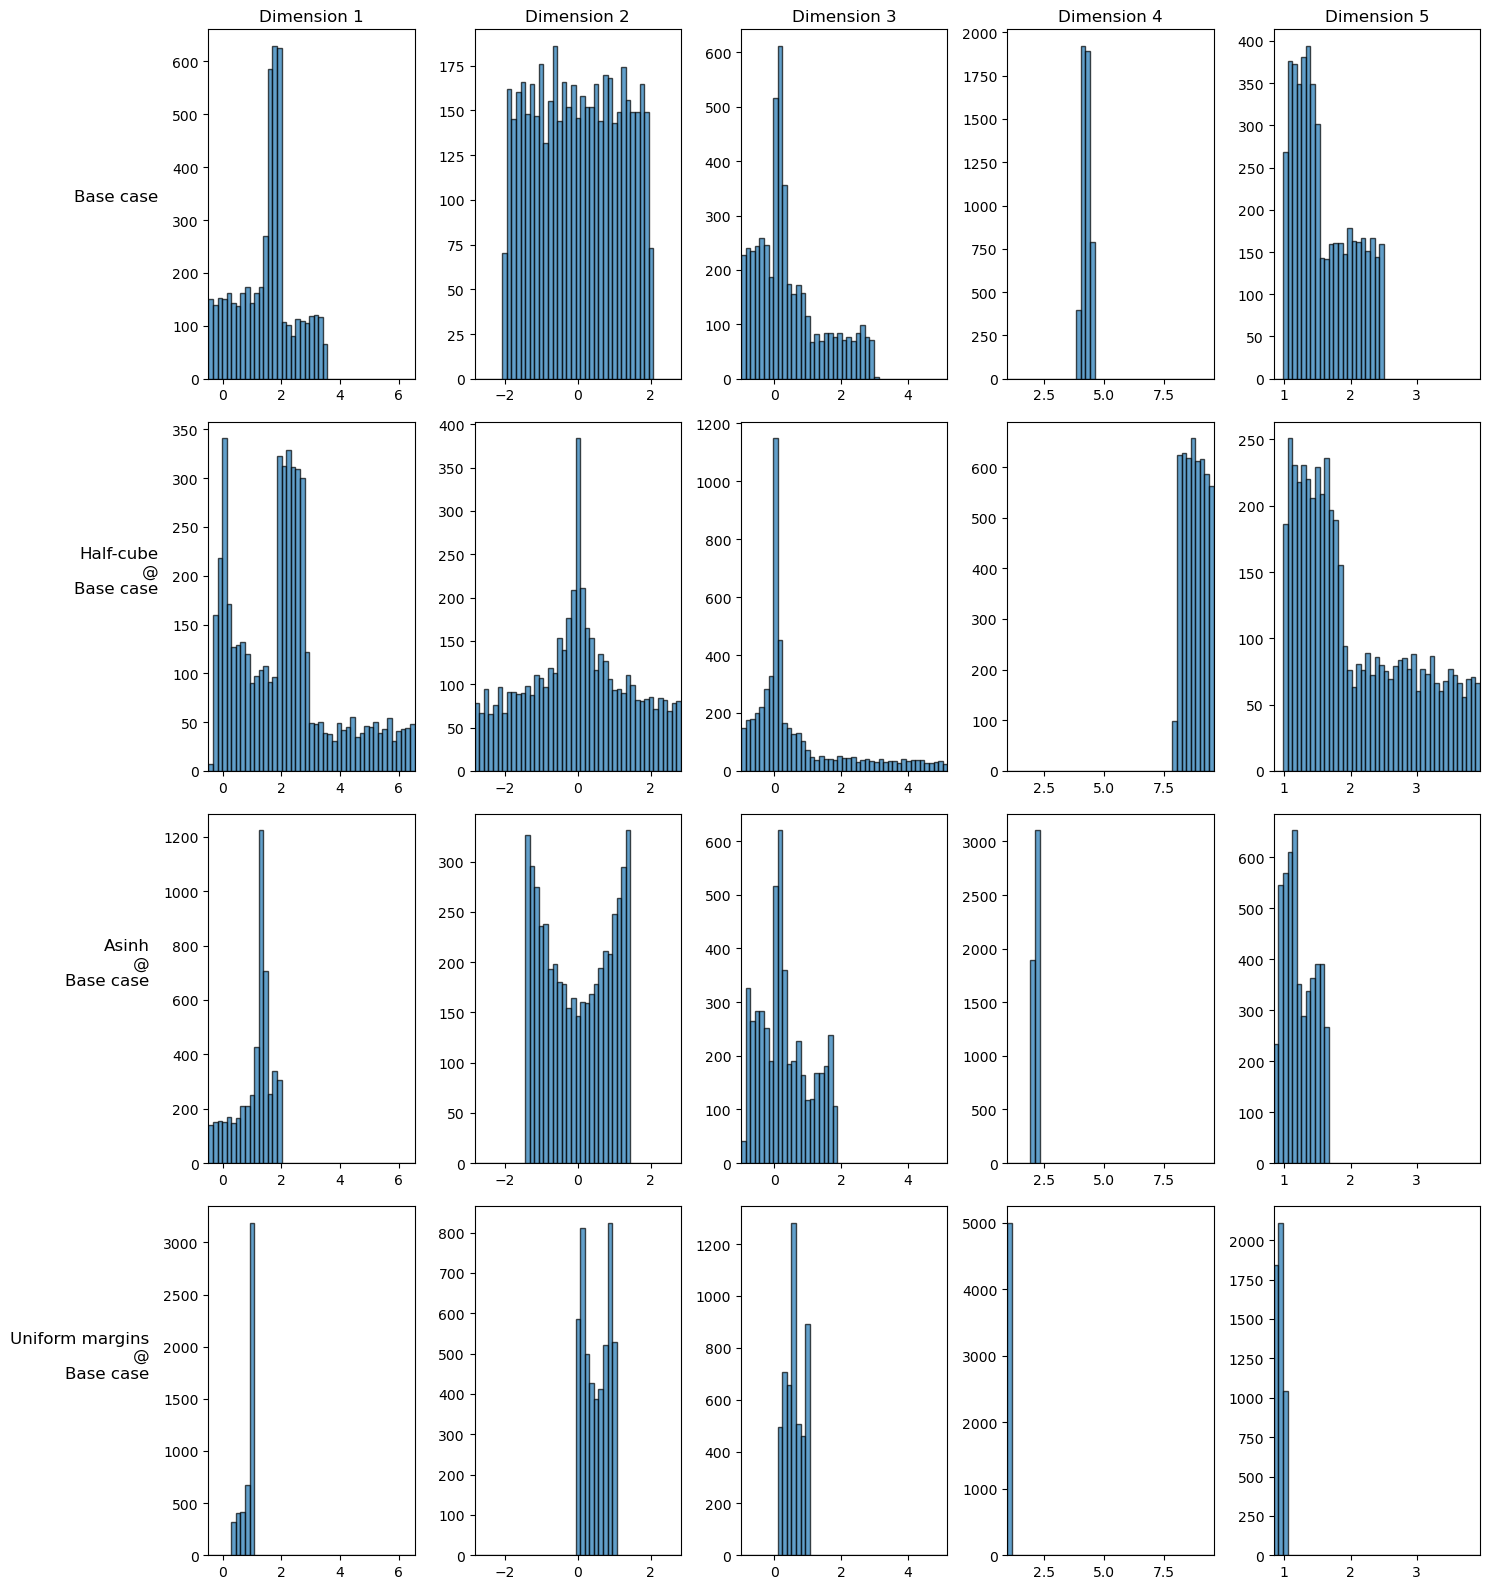

In [9]:
# Plot the distribution of each dimension
datasets = [x_sample, half_cube_x_sample, asinh_x_sample, uniform_x_sample]
data_names = ["Base case", "Half-cube\n@\nBase case", "Asinh\n@\nBase case", "Uniform margins\n@\nBase case"]

plot_dim_distribution(datasets=datasets, data_names=data_names, savefig=False)

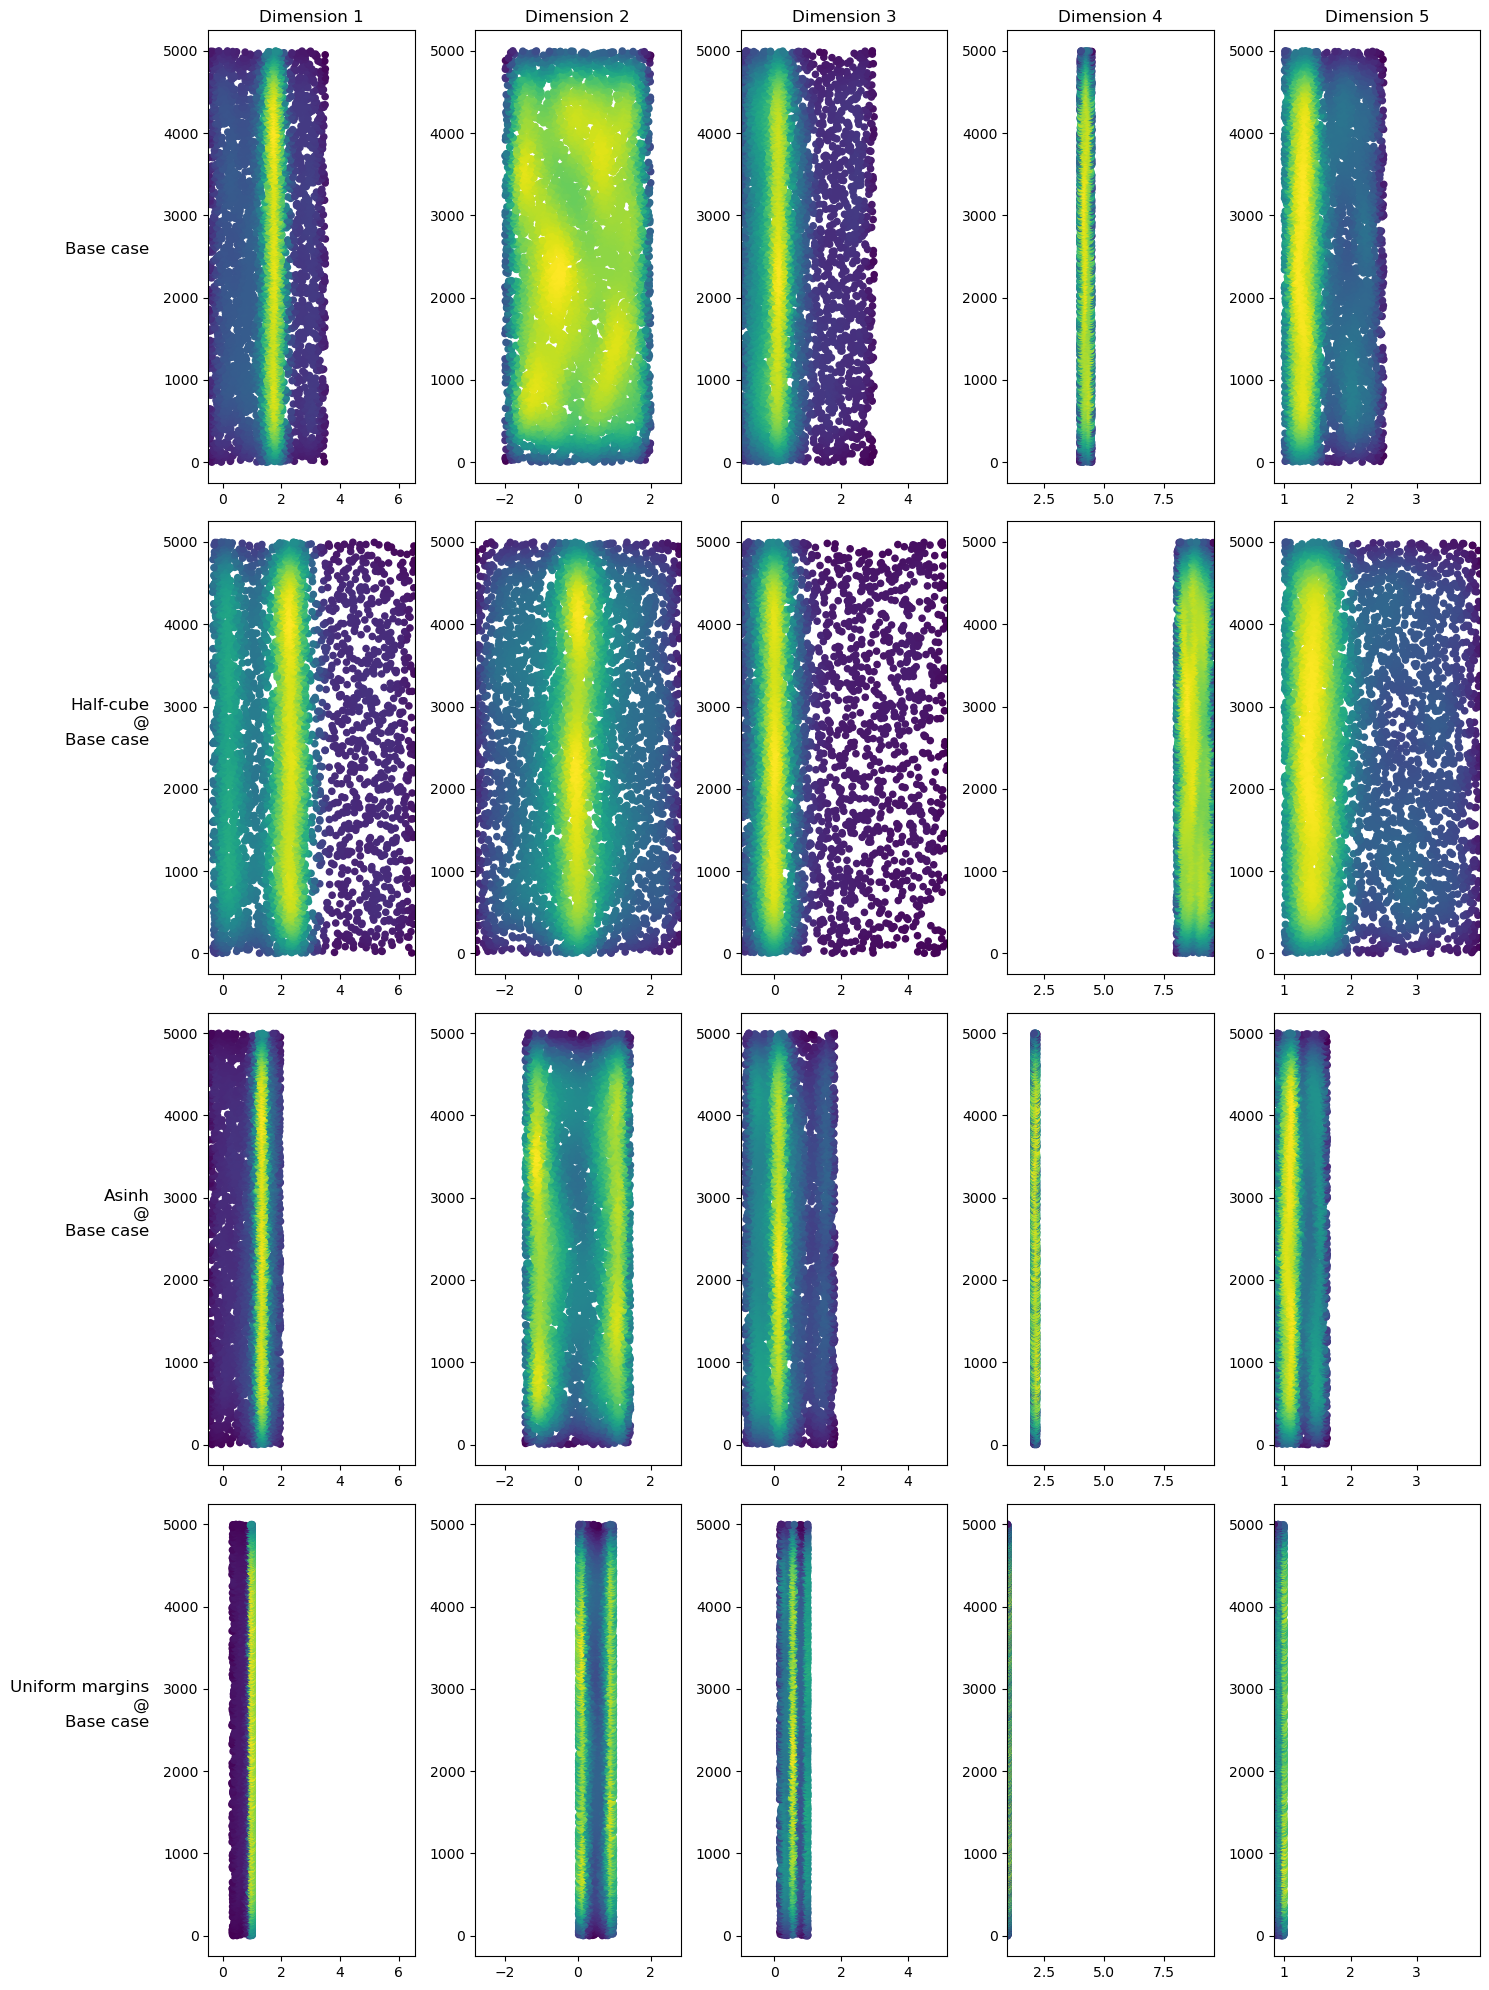

In [10]:
plot_dim_density(datasets=datasets, data_names=data_names, savefig=False)

## Gaussian Distribution Case 5-dimensional

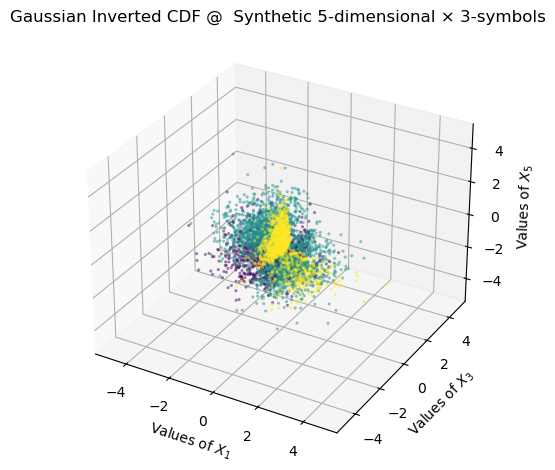

In [13]:
n_samples=5_000
gaussian_cdf_transf = gaussian_cdf(base_task=synthetic_dist_study)
gaussian_x_sample, gaussian_y_sample  = gaussian_cdf_transf.sample(n_samples=n_samples, seed=SEED)

# Apply half-cube mapping
half_cube_map = half_cube(gaussian_cdf_transf)
half_cube_x_sample, half_cube_y_sample = half_cube_map.sample(n_samples=n_samples, seed=SEED)

# Apply asinh mapping
asinh_map = asinh(gaussian_cdf_transf)
asinh_x_sample, asinh_y_sample = asinh_map.sample(n_samples=n_samples, seed=SEED)

# Apply uniform margins transformation
uniform_margins_map = uniform_margins(gaussian_cdf_transf)
uniform_x_sample, uniform_y_sample = uniform_margins_map.sample(n_samples=n_samples, seed=SEED)

# Plot the 3D figure of the sampled data points
plot_3d_figure(
    X=gaussian_x_sample,                  
    y=gaussian_y_sample,                           
    cell_boundaries=study_scenario['cell_bound'],       
    title=gaussian_cdf_transf.name,  
    savedata=False
)

 22%|███████████▋                                        | 2250/10000 [01:24<04:52, 26.48step/s, test=-0.00, train=0.00]


  8%|███▉                                                 | 750/10000 [00:30<06:19, 24.37step/s, test=-0.00, train=0.00]


 15%|███████▉                                             | 1500/10000 [00:56<05:21, 26.46step/s, test=0.11, train=0.06]


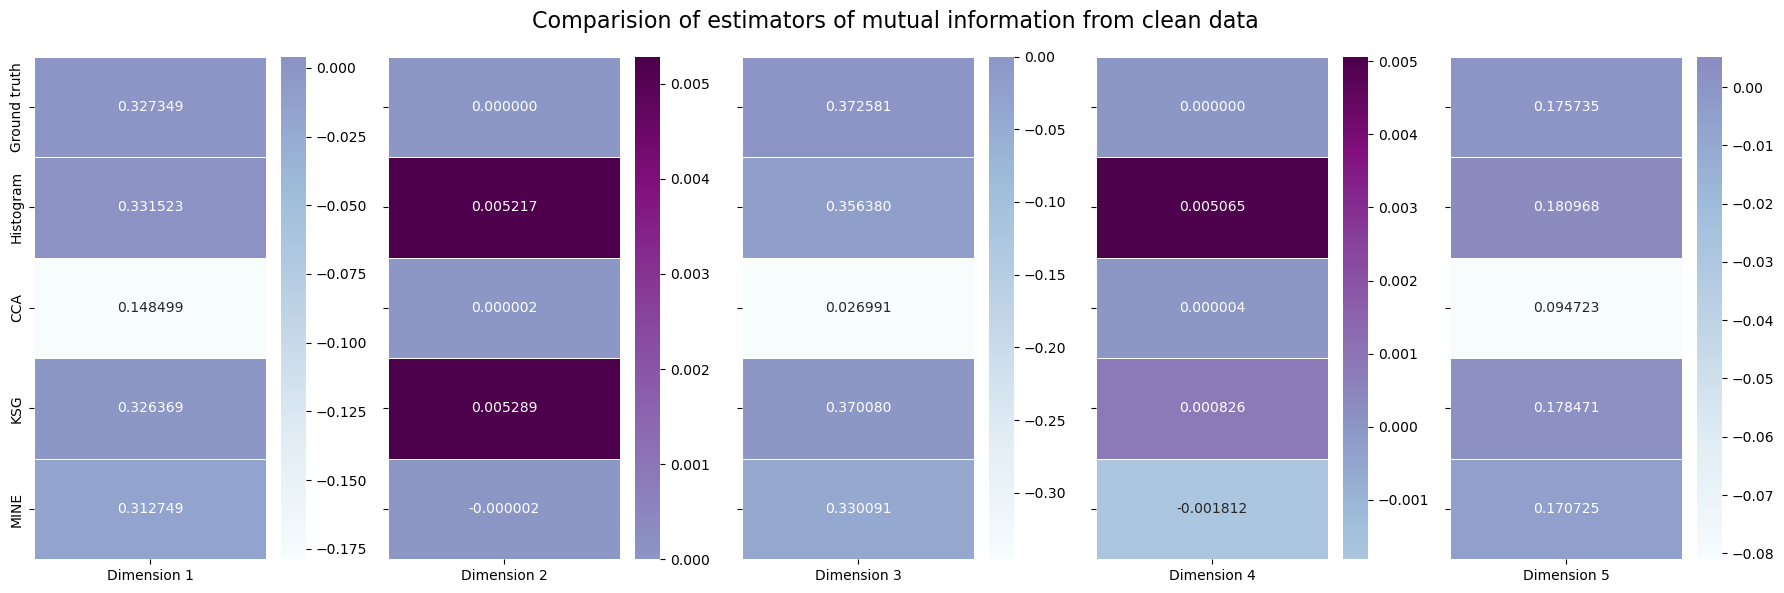

CPU times: total: 40.5 s
Wall time: 5min 23s


In [8]:
%%time
# Estimate mutual information of each dimension
ground_truth_gauss = [gaussian_cdf_transf.sampler.get_metadata()[f"mi_{i}"] for i in range(1, gaussian_x_sample.shape[1]+1)]
compare_EMI(X=gaussian_x_sample, y=gaussian_y_sample, ground_truth=ground_truth_gauss, add_noise=False, title=True)

 22%|███████████▍                                       | 2250/10000 [03:13<11:06, 11.62step/s, test=-0.00, train=-0.00]


  8%|███▉                                                 | 750/10000 [00:29<05:58, 25.81step/s, test=-0.00, train=0.00]


 15%|███████▉                                             | 1500/10000 [00:56<05:20, 26.49step/s, test=0.11, train=0.07]


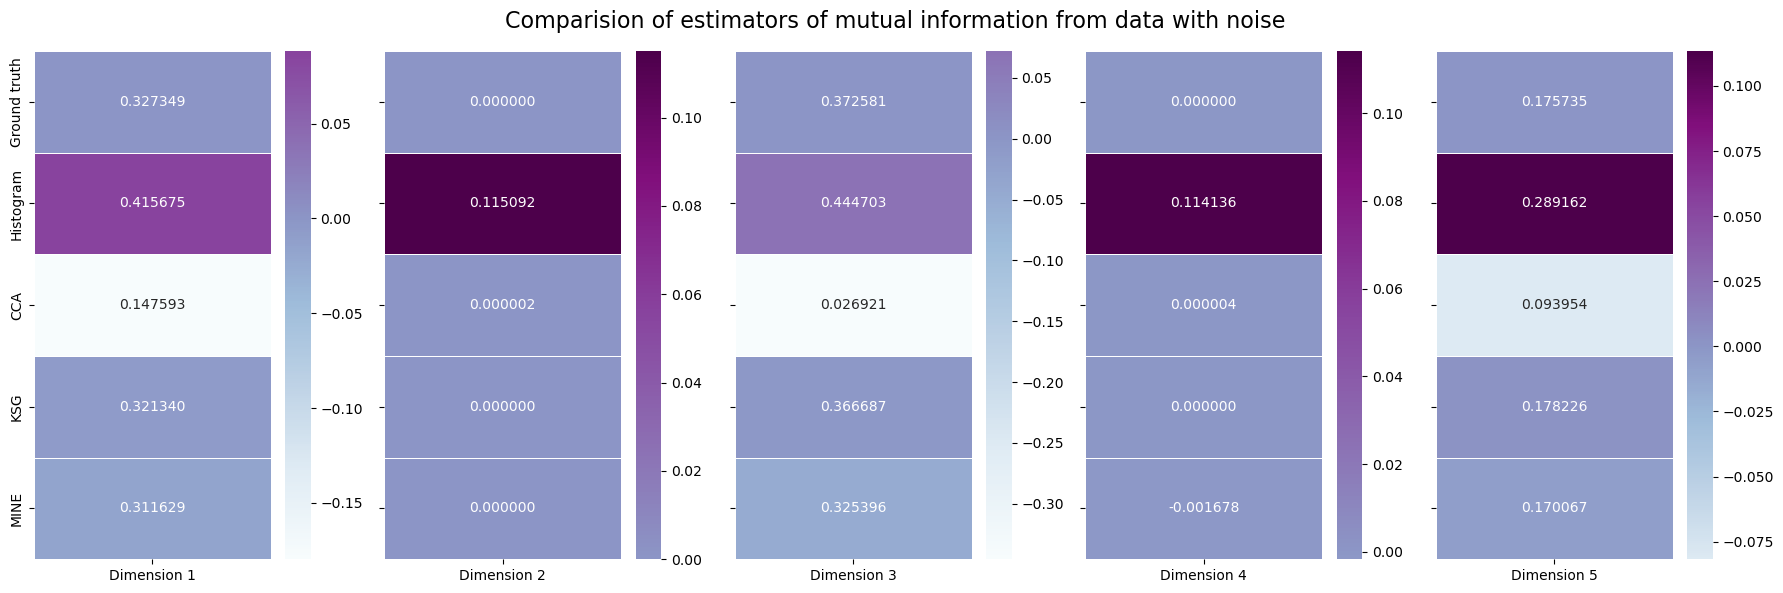

In [9]:
# Estimate mutual information of each dimension
ground_truth_gauss = [gaussian_cdf_transf.sampler.get_metadata()[f"mi_{i}"] for i in range(1, gaussian_x_sample.shape[1]+1)]
compare_EMI(X=gaussian_x_sample, y=gaussian_y_sample, ground_truth=ground_truth_gauss, add_noise=True, title=True)

 18%|█████████▎                                           | 1750/10000 [01:04<05:05, 27.02step/s, test=0.62, train=0.46]


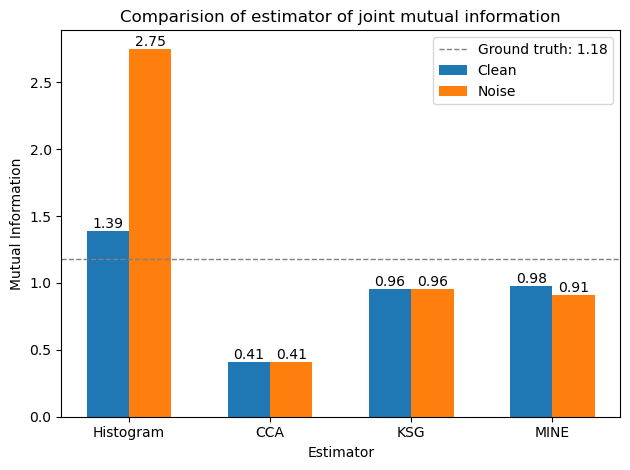

In [10]:
ground_truth = round(synthetic_dist_study.mutual_information, 2)
compare_joint_EMI(X=gaussian_x_sample, y=gaussian_y_sample, ground_truth=ground_truth, title=True)

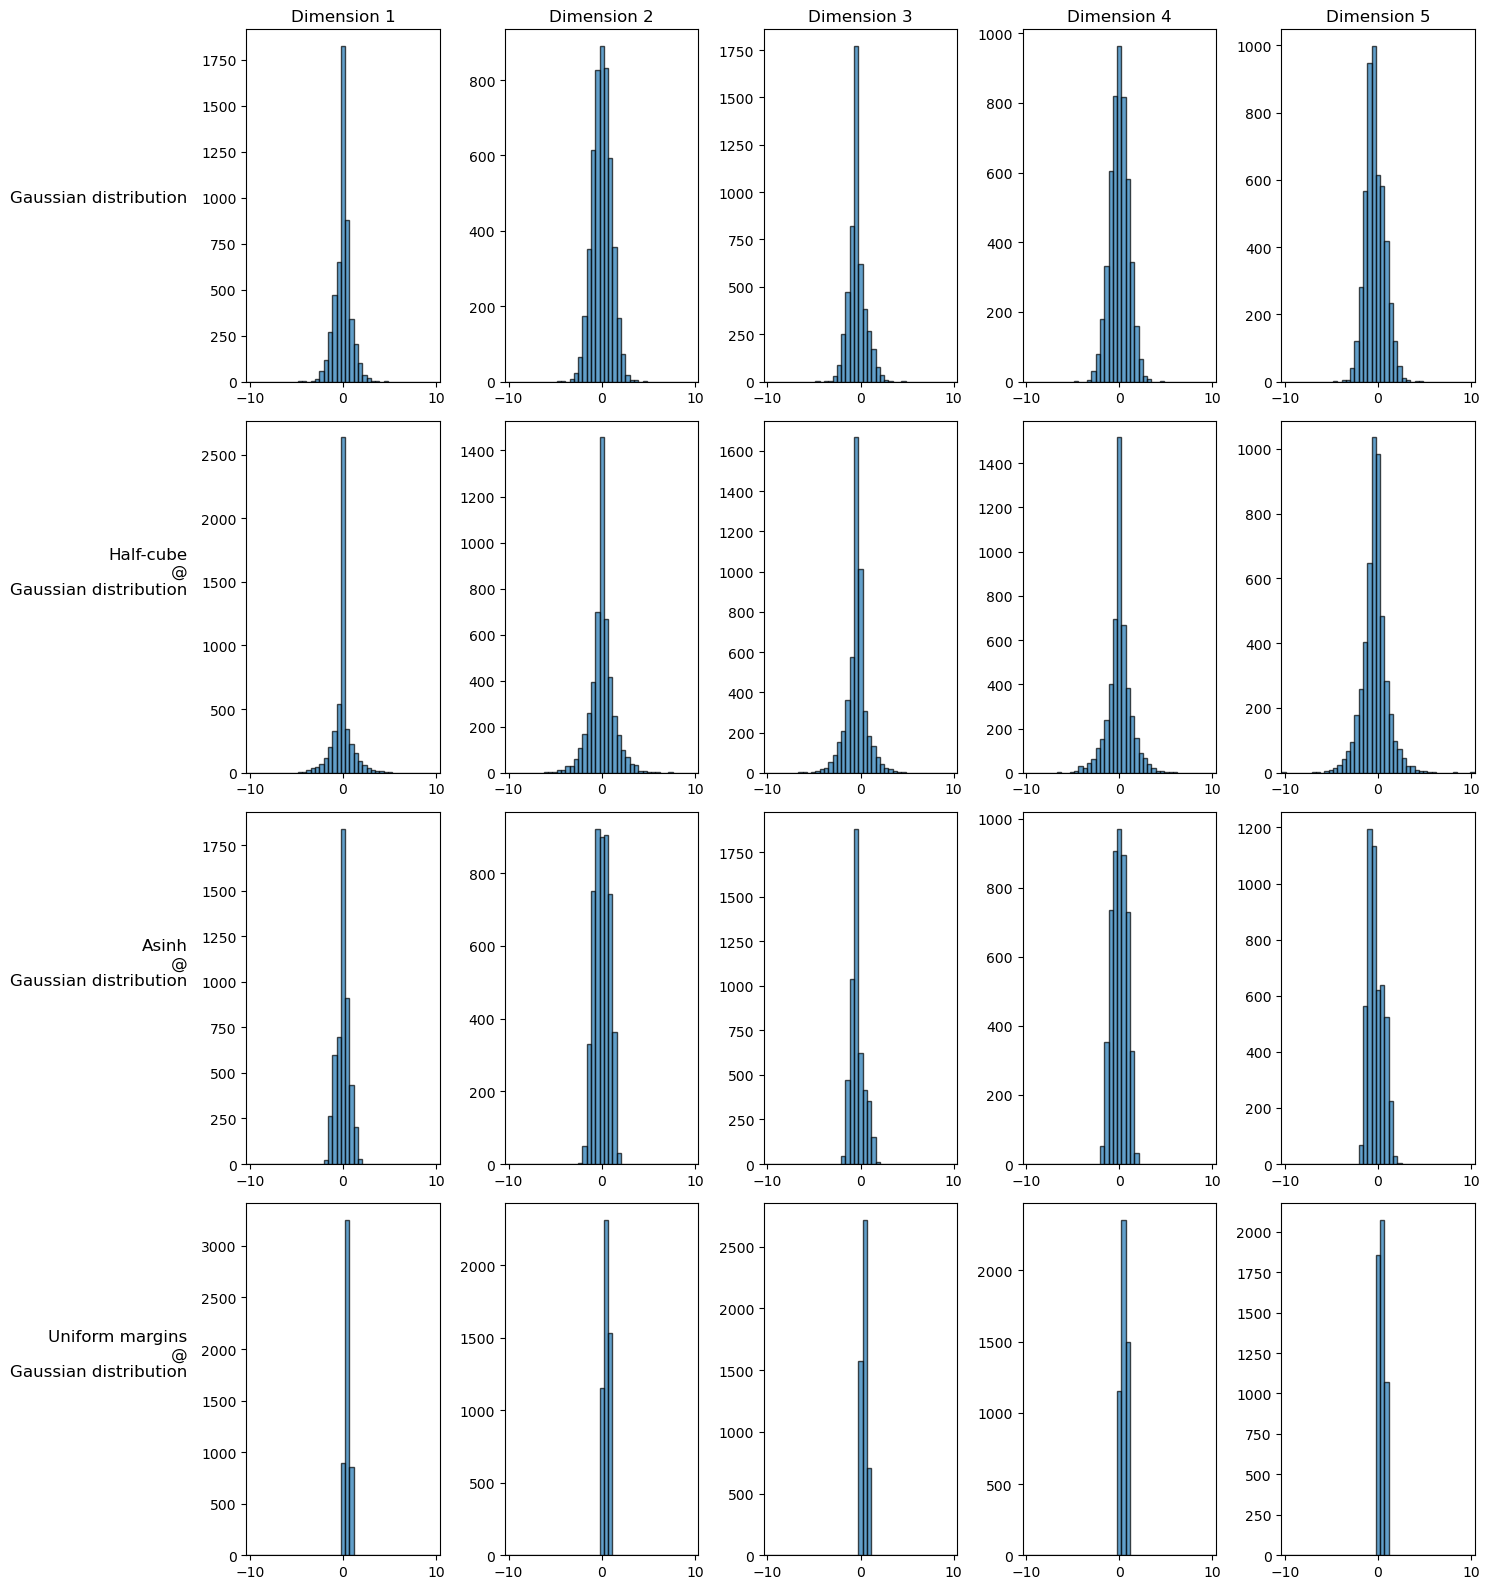

In [14]:
datasets = [gaussian_x_sample, half_cube_x_sample, asinh_x_sample, uniform_x_sample]
data_names = ["Gaussian distribution", "Half-cube\n@\nGaussian distribution", "Asinh\n@\nGaussian distribution", "Uniform margins\n@\nGaussian distribution"]

plot_dim_distribution(datasets=datasets, data_names=data_names, savefig=False)

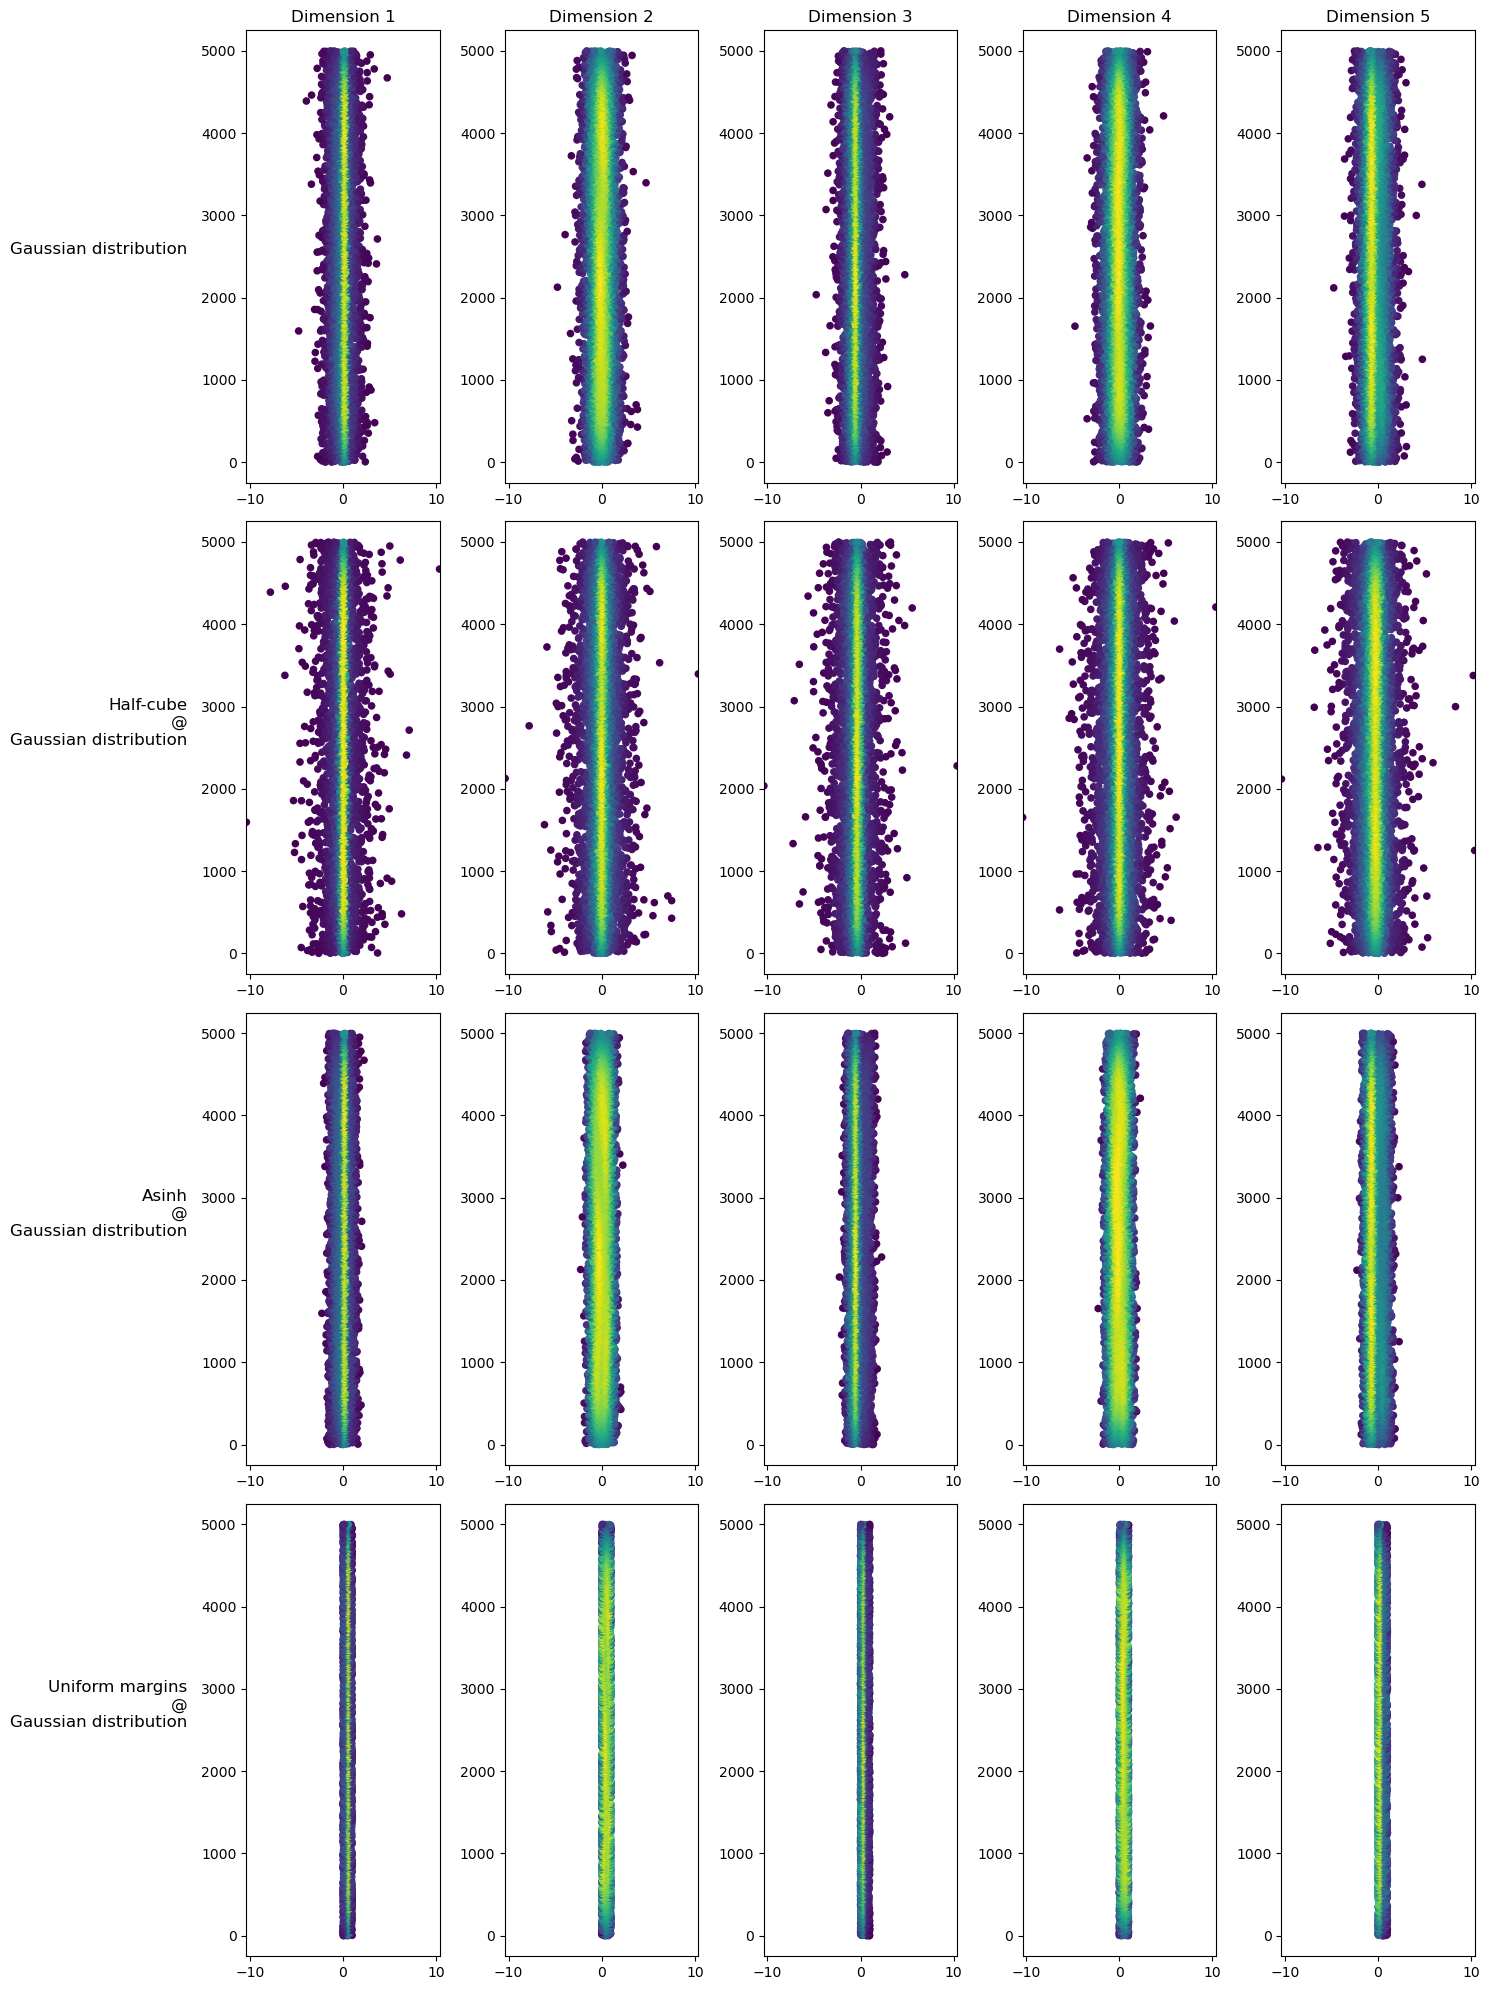

In [15]:
plot_dim_density(datasets=datasets, data_names=data_names, savefig=False)

## t-Student Distribution Case 5-dimensional

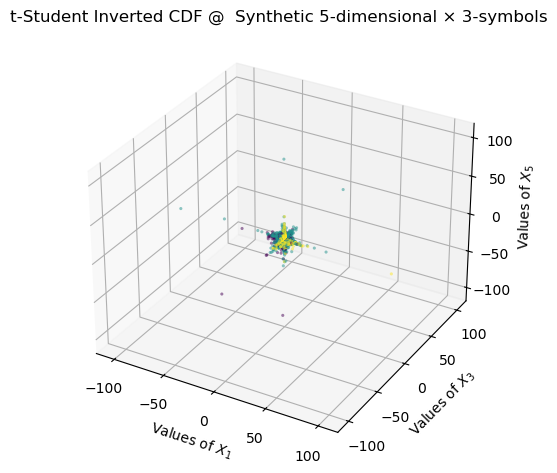

In [19]:
df = 3  # Degrees of freedom 
n_samples=50_000
student_cdf_transf = student_cdf(base_task=synthetic_dist_study, df=df)
student_x_sample, student_y_sample = student_cdf_transf.sample(n_samples=n_samples, seed=SEED)

# Apply half-cube mapping
half_cube_map = half_cube(student_cdf_transf)
half_cube_x_sample, half_cube_y_sample = half_cube_map.sample(n_samples=n_samples, seed=SEED)

# Apply asinh mapping
asinh_map = asinh(student_cdf_transf)
asinh_x_sample, asinh_y_sample = asinh_map.sample(n_samples=n_samples, seed=SEED)

# Apply uniform margins transformation
uniform_margins_map = uniform_margins(student_cdf_transf)
uniform_x_sample, uniform_y_sample = uniform_margins_map.sample(n_samples=n_samples, seed=SEED)

# Plot the 3D figure of the sampled data points
plot_3d_figure(
    X=student_x_sample,                  
    y=student_y_sample,                           
    cell_boundaries=study_scenario['cell_bound'],      
    title=student_cdf_transf.name,
    savedata=False  
)

 10%|█████▏                                              | 1000/10000 [00:38<05:46, 26.01step/s, test=-0.00, train=0.00]


 20%|██████████▏                                        | 2000/10000 [01:15<05:03, 26.37step/s, test=-0.00, train=-0.00]


 15%|███████▉                                             | 1500/10000 [00:56<05:22, 26.33step/s, test=0.10, train=0.06]


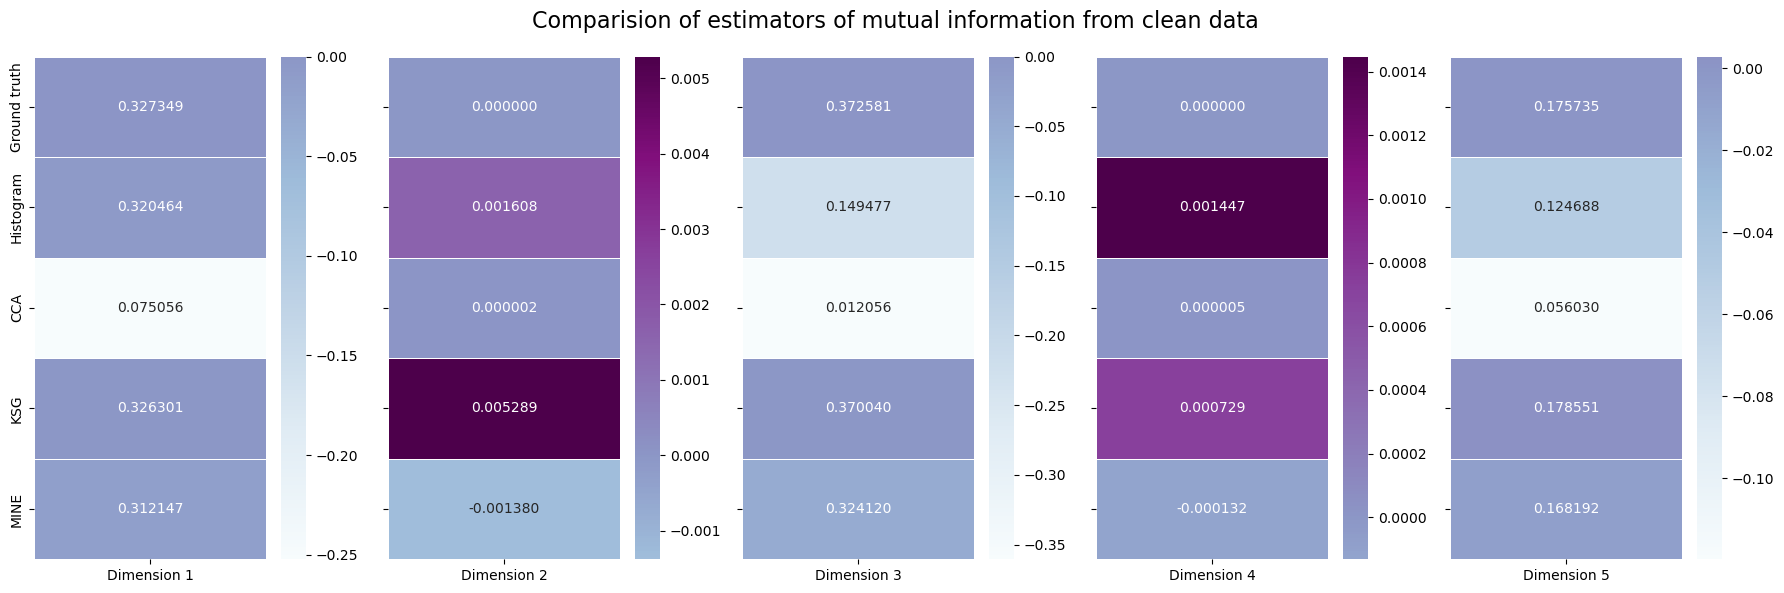

CPU times: total: 44.6 s
Wall time: 4min 49s


In [16]:
%%time
# Estimate mutual information of each dimension
ground_truth_stud = [student_cdf_transf.sampler.get_metadata()[f"mi_{i}"] for i in range(1, student_x_sample.shape[1]+1)]
compare_EMI(X=student_x_sample, y=student_y_sample, ground_truth=ground_truth_stud, add_noise=False, title=True)

 10%|█████▏                                              | 1000/10000 [00:37<05:33, 26.99step/s, test=-0.00, train=0.00]


 12%|██████▍                                            | 1250/10000 [01:41<11:47, 12.37step/s, test=-0.00, train=-0.01]


 15%|███████▉                                             | 1500/10000 [02:25<13:46, 10.28step/s, test=0.10, train=0.06]


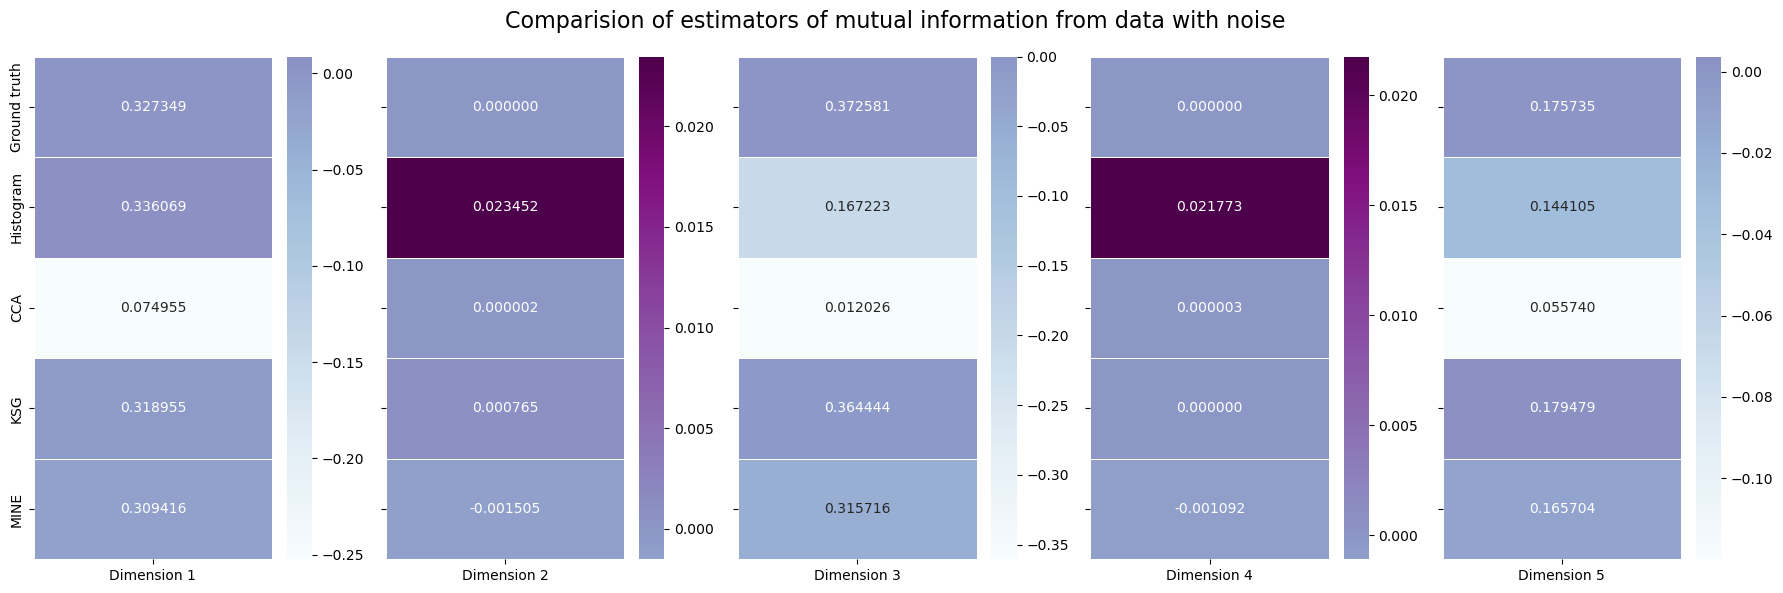

In [17]:
# Estimate mutual information of each dimension
ground_truth_stud = [student_cdf_transf.sampler.get_metadata()[f"mi_{i}"] for i in range(1, student_x_sample.shape[1]+1)]
compare_EMI(X=student_x_sample, y=student_y_sample, ground_truth=ground_truth_stud, add_noise=True, title=True)

 20%|██████████▌                                          | 2000/10000 [01:18<05:12, 25.57step/s, test=0.60, train=0.52]


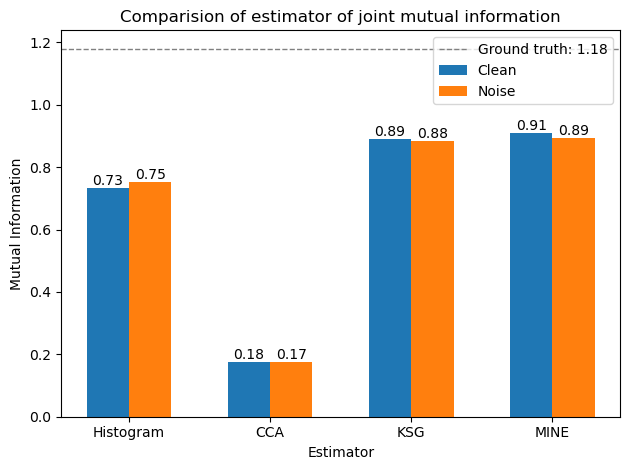

In [52]:
ground_truth = round(synthetic_dist_study.mutual_information, 2)
compare_joint_EMI(X=student_x_sample, y=student_y_sample, ground_truth=ground_truth, title=True)

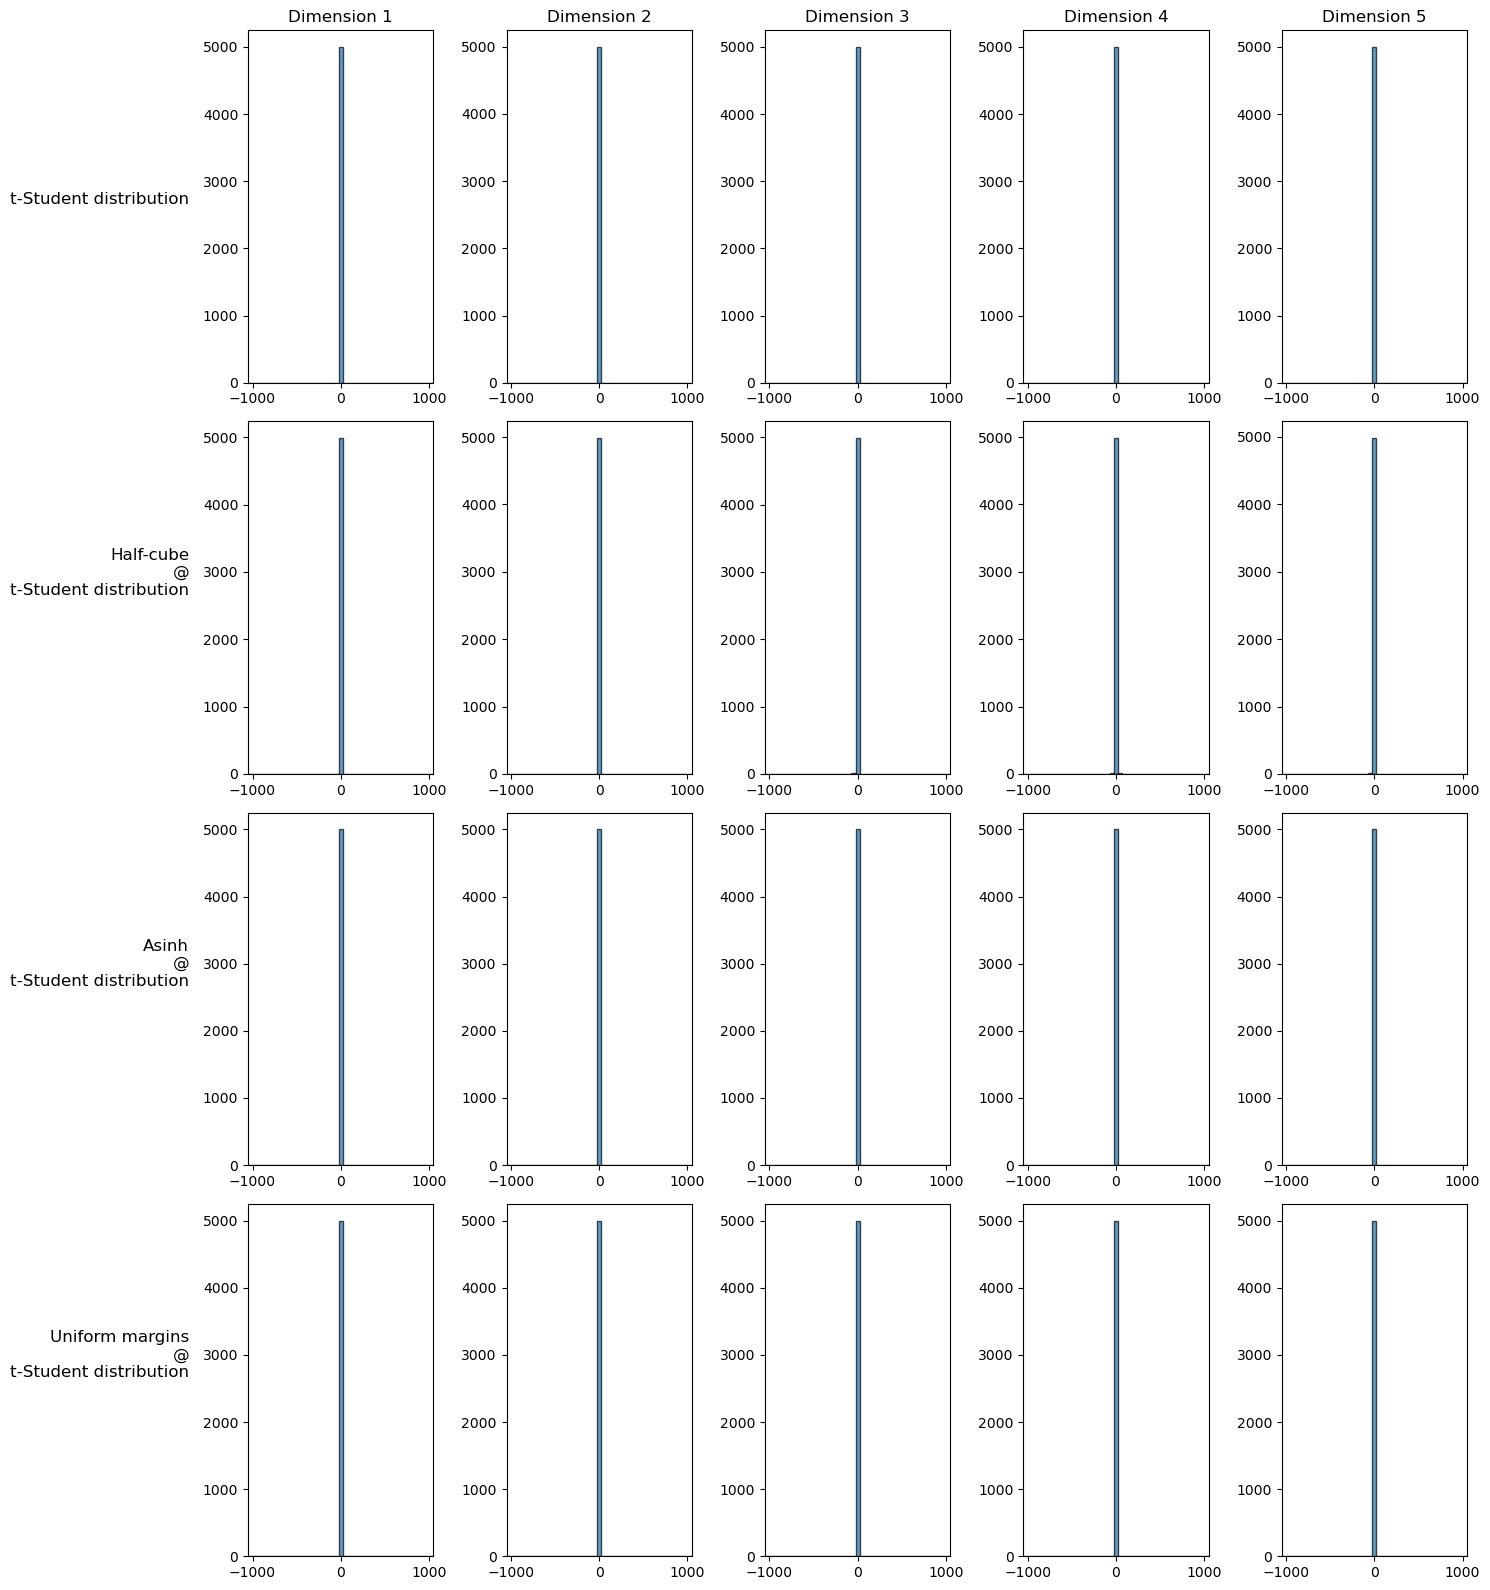

In [17]:
datasets = [student_x_sample, half_cube_x_sample, asinh_x_sample, uniform_x_sample]
data_names = ["t-Student distribution", "Half-cube\n@\nt-Student distribution", "Asinh\n@\nt-Student distribution", "Uniform margins\n@\nt-Student distribution"]

plot_dim_distribution(datasets=datasets, data_names=data_names, savefig=False)

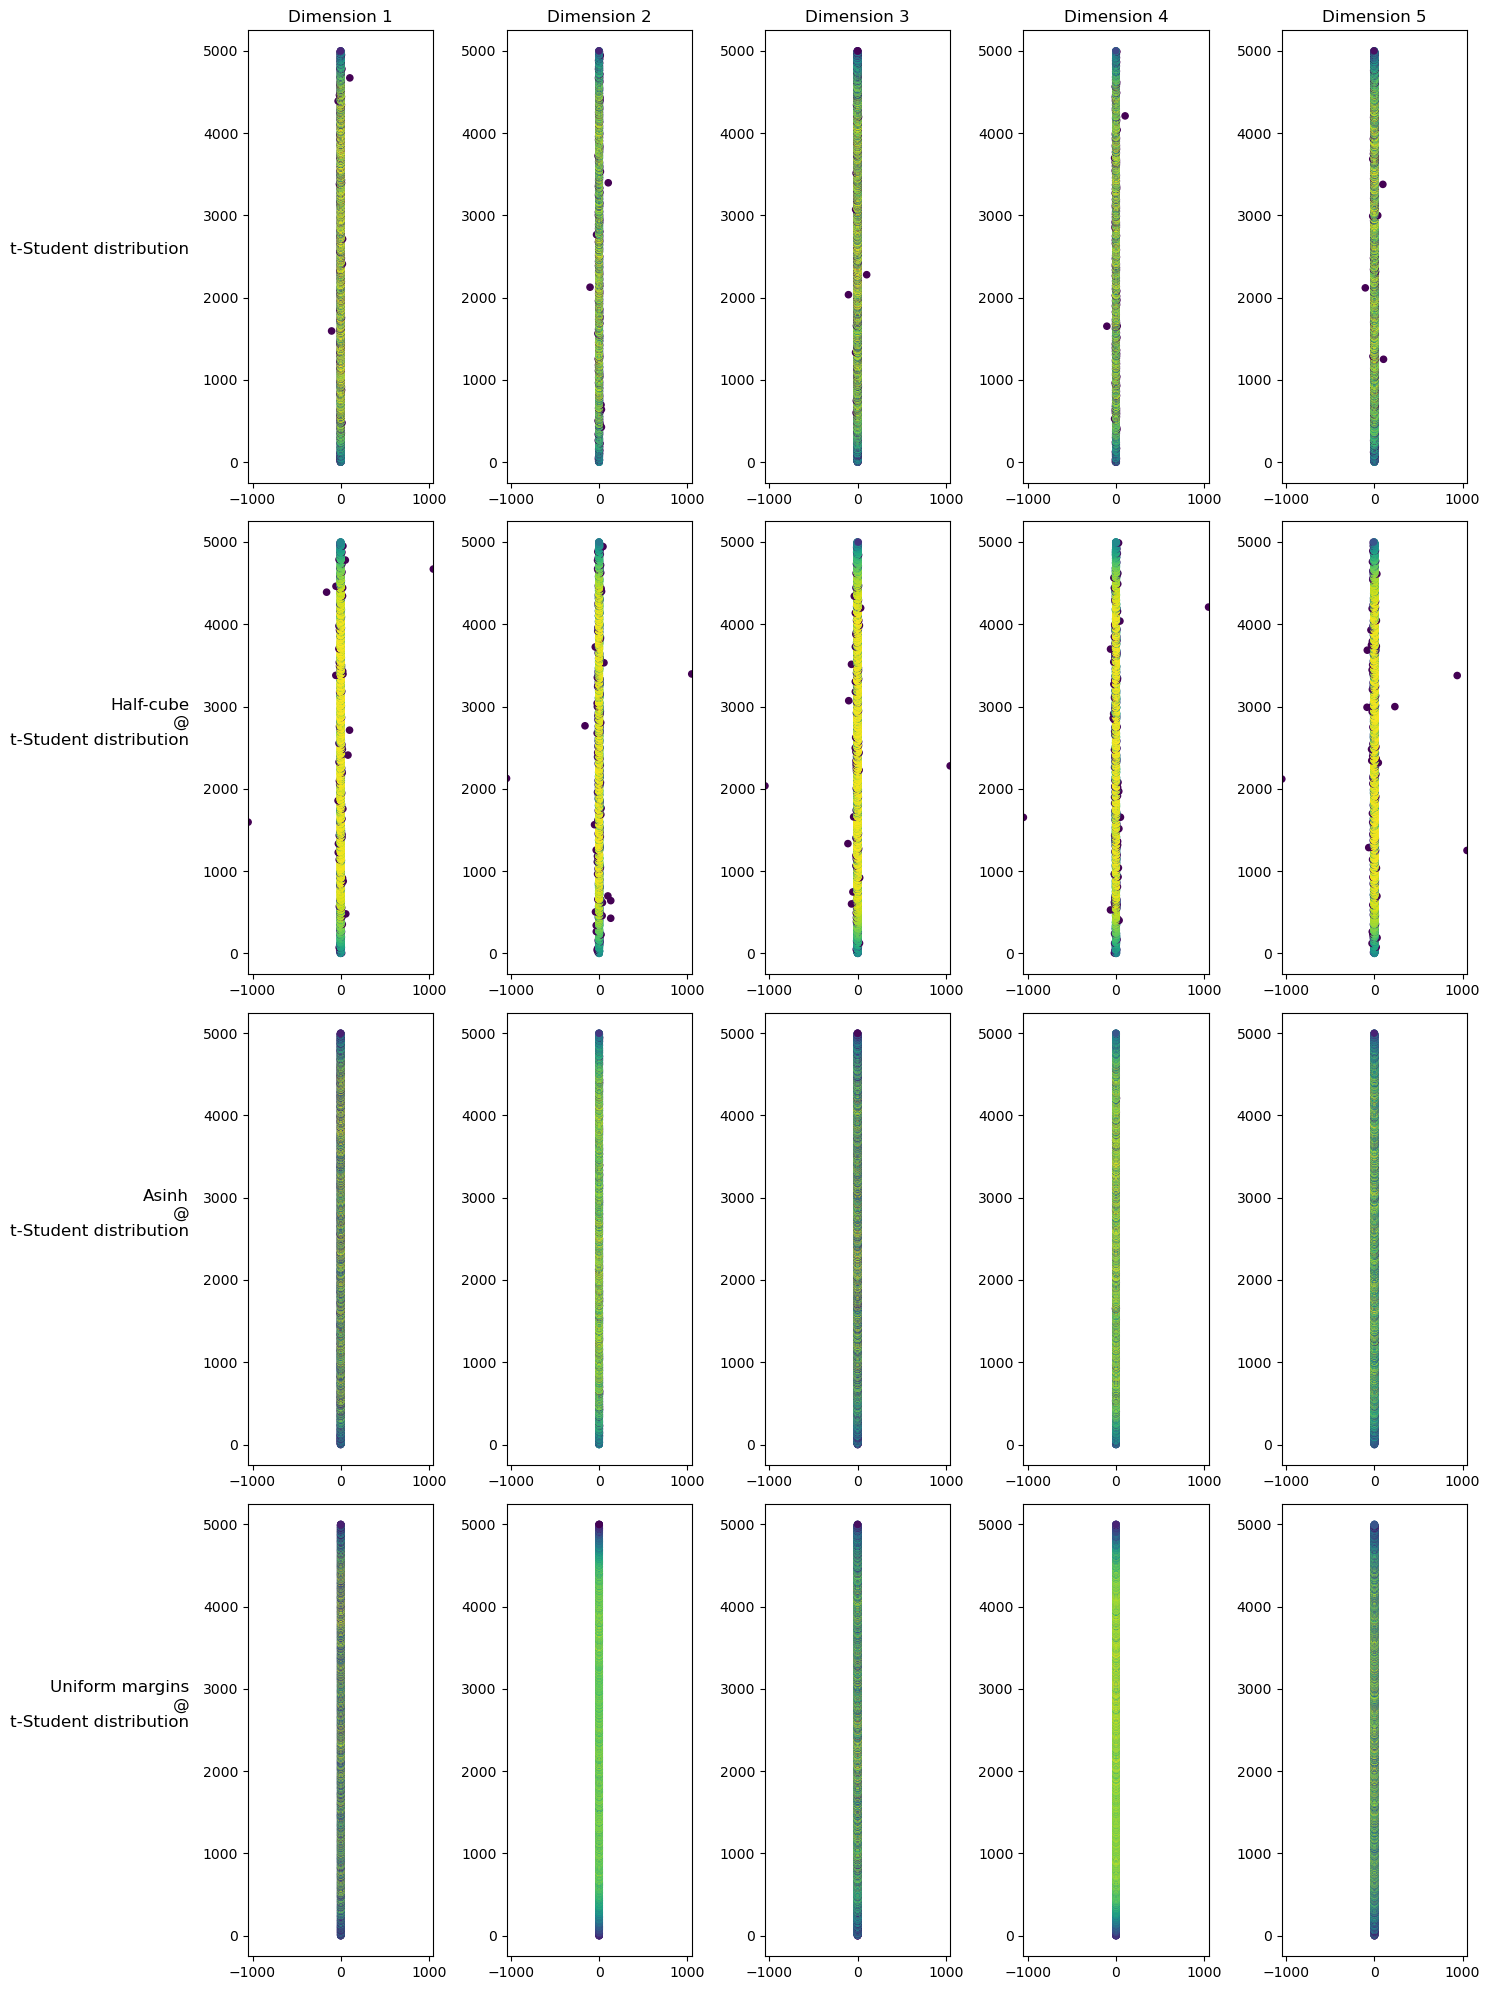

In [18]:
plot_dim_density(datasets=datasets, data_names=data_names, savefig=False)

## General Analysis

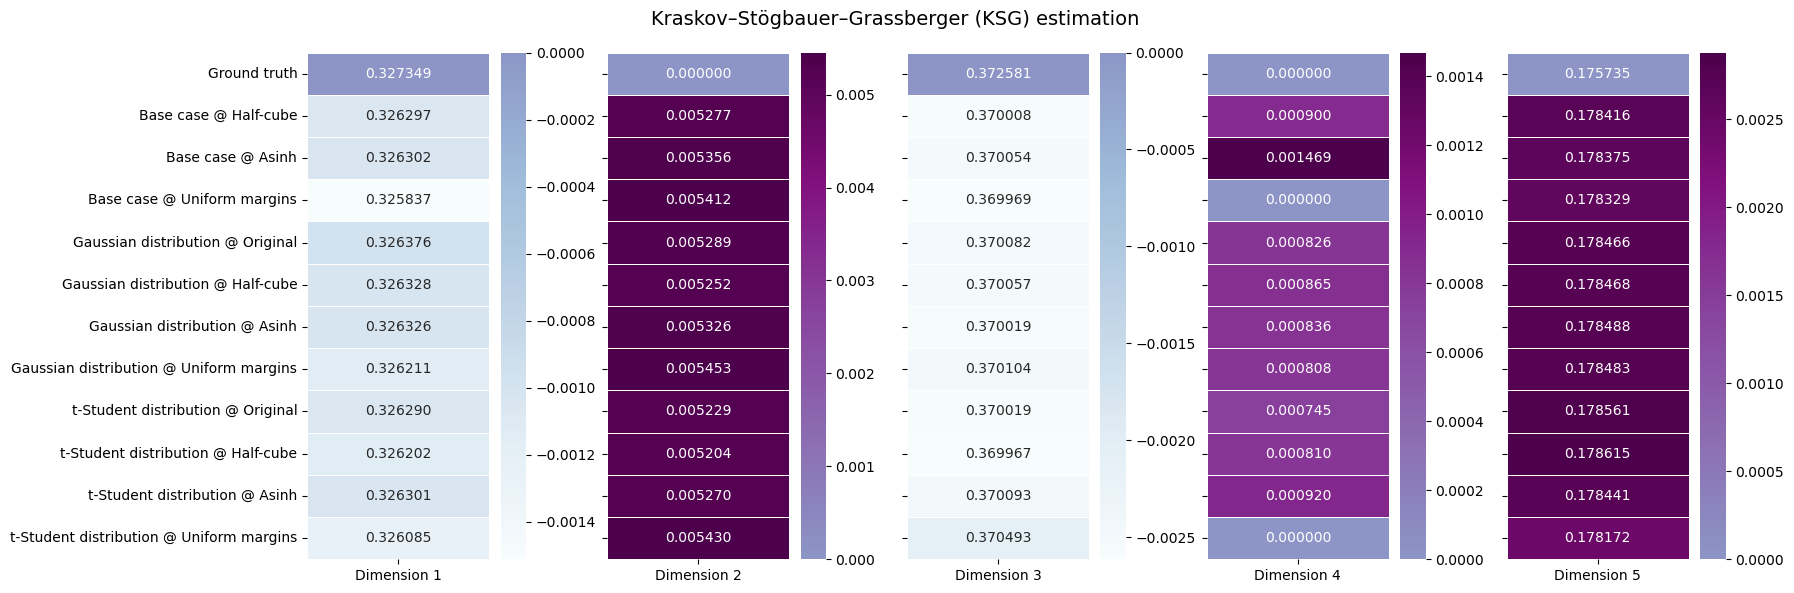

In [57]:
n_samples=50_000
bench_mi_transformations(title=True, add_noise=False, n_samples=n_samples)

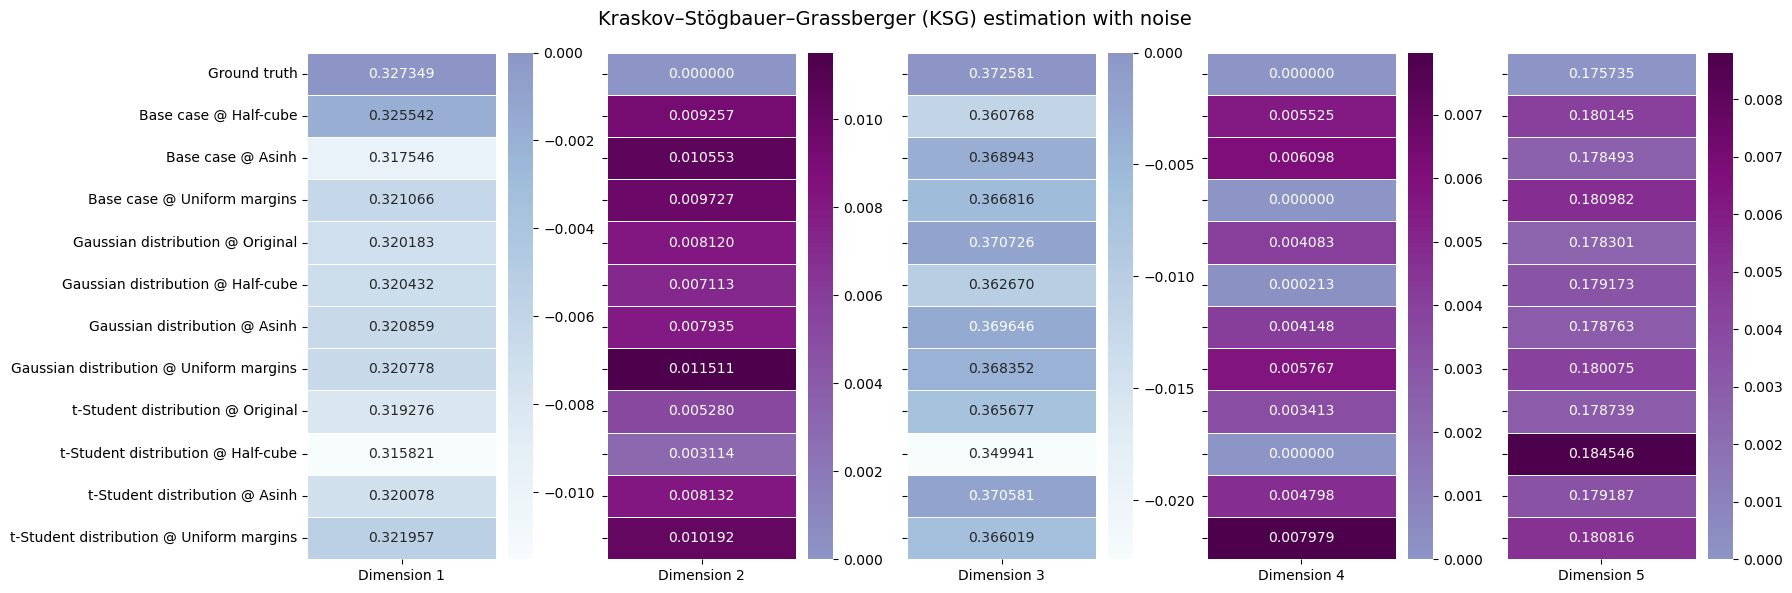

In [58]:
bench_mi_transformations(title=True, add_noise=True, n_samples=n_samples)

When analyzing the joint mutual information of each transformation using the KSG estimator, it is observed that in most cases, the results approach the ground truth. The differences are caused by the implemented method and the number of samples used, as only 50k samples were utilized due to computational time constraints.

Moreover, this graph highlights the difficulty of estimating mutual information for heavy-tailed distributions, such as in the case of half-cube transformations. These transformations extend the tails of the distributions, leading to lower estimates that deviate more from the ground truth.

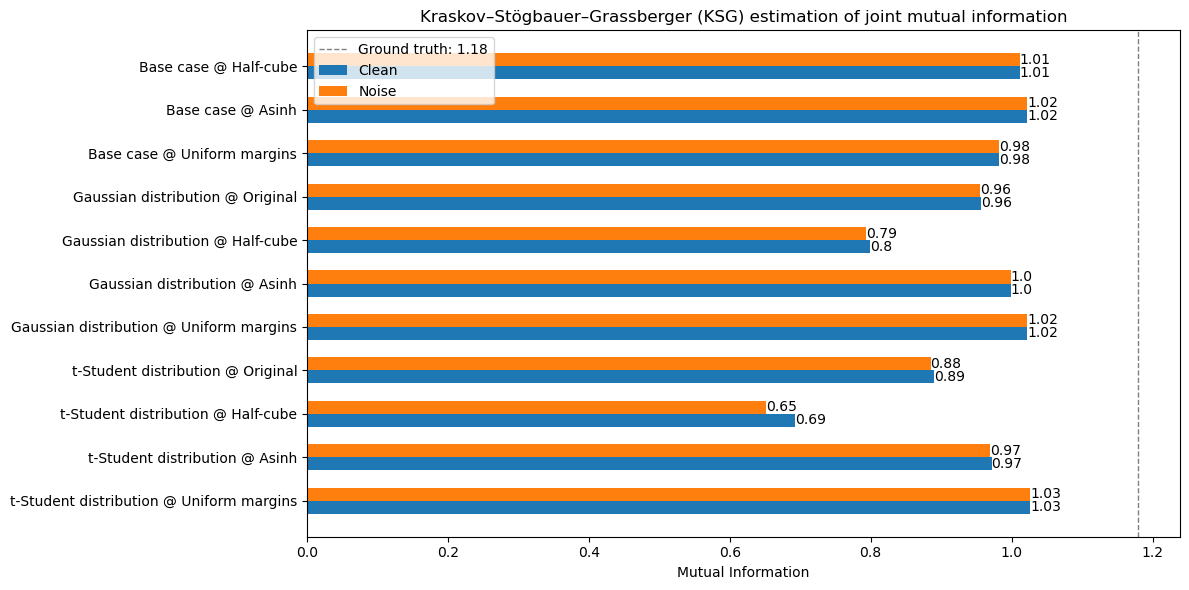

In [7]:
ground_truth = round(synthetic_dist_study.mutual_information, 2)
bench_joint_mi_transformations(n_samples=n_samples, ground_truth=ground_truth, title=True)

## Swissroll analysis

A method was implemented to increase the dimensionality of the data by successively applying the Swissroll transformation, which doubles the original dimensions. For example, if the original data has 5 dimensions, one Swissroll transformation will result in 10-dimensional data; applying two consecutive Swissroll transformations will yield 20-dimensional data; and applying three Swissroll transformations will produce 40-dimensional data, and so on.

Furthermore, the preservation of mutual information through these transformations was evaluated. Specifically, the mutual information was estimated for both individual dimensions and the sets of duplicated dimensions derived from a single original dimension. For instance, after applying one Swissroll transformation, the resulting data will have 10 dimensions, where the first two dimensions derive from the first dimension of the original data. Therefore, the mutual information of this original dimension was compared with the joint mutual information of the two resulting dimensions. This analysis was carried out over the application of six consecutive Swissroll transformations.

In [5]:
%%capture
import bmi

num_samples=10_000
# Sample data points from the synthetic distribution 
x_sample, y_sample = synthetic_dist_study.sample(n_samples=num_samples, seed=SEED)

# Generate synthetic Swiss roll data with different numbers of Swiss rolls (1 to 6)
X_swiss_1 = dim_augmented(num_swiss=1, n_samples=num_samples)
X_swiss_2 = dim_augmented(num_swiss=2, n_samples=num_samples)
X_swiss_3 = dim_augmented(num_swiss=3, n_samples=num_samples)
X_swiss_4 = dim_augmented(num_swiss=4, n_samples=num_samples)
X_swiss_5 = dim_augmented(num_swiss=5, n_samples=num_samples)
X_swiss_6 = dim_augmented(num_swiss=6, n_samples=num_samples)

# Retrieve ground truth Mutual Information (MI) values for each dimension from metadata
ground_truth = [synthetic_dist_study.sampler.get_metadata()[f"mi_{i}"] for i in range(1, x_sample.shape[1]+1)]

# Initialize the MINE estimator and calculate the estimated MI for different Swiss roll dimensions
estimator = bmi.estimators.MINEEstimator()
swiss_1_mi = [estimator.estimate(X_swiss_1[:,i:i+2], y_sample.reshape(-1,1))/np.log(2) for i in range(0, X_swiss_1.shape[1], 2)]
estimator = bmi.estimators.MINEEstimator()
swiss_2_mi = [estimator.estimate(X_swiss_2[:,i:i+4], y_sample.reshape(-1,1))/np.log(2) for i in range(0, X_swiss_2.shape[1], 4)]
estimator = bmi.estimators.MINEEstimator()
swiss_3_mi = [estimator.estimate(X_swiss_3[:,i:i+8], y_sample.reshape(-1,1))/np.log(2) for i in range(0, X_swiss_3.shape[1], 8)]
estimator = bmi.estimators.MINEEstimator()
swiss_4_mi = [estimator.estimate(X_swiss_4[:,i:i+16], y_sample.reshape(-1,1))/np.log(2) for i in range(0, X_swiss_4.shape[1], 16)]
estimator = bmi.estimators.MINEEstimator()
swiss_5_mi = [estimator.estimate(X_swiss_5[:,i:i+32], y_sample.reshape(-1,1))/np.log(2) for i in range(0, X_swiss_5.shape[1], 32)]
estimator = bmi.estimators.MINEEstimator()
swiss_6_mi = [estimator.estimate(X_swiss_6[:,i:i+64], y_sample.reshape(-1,1))/np.log(2) for i in range(0, X_swiss_6.shape[1], 64)]

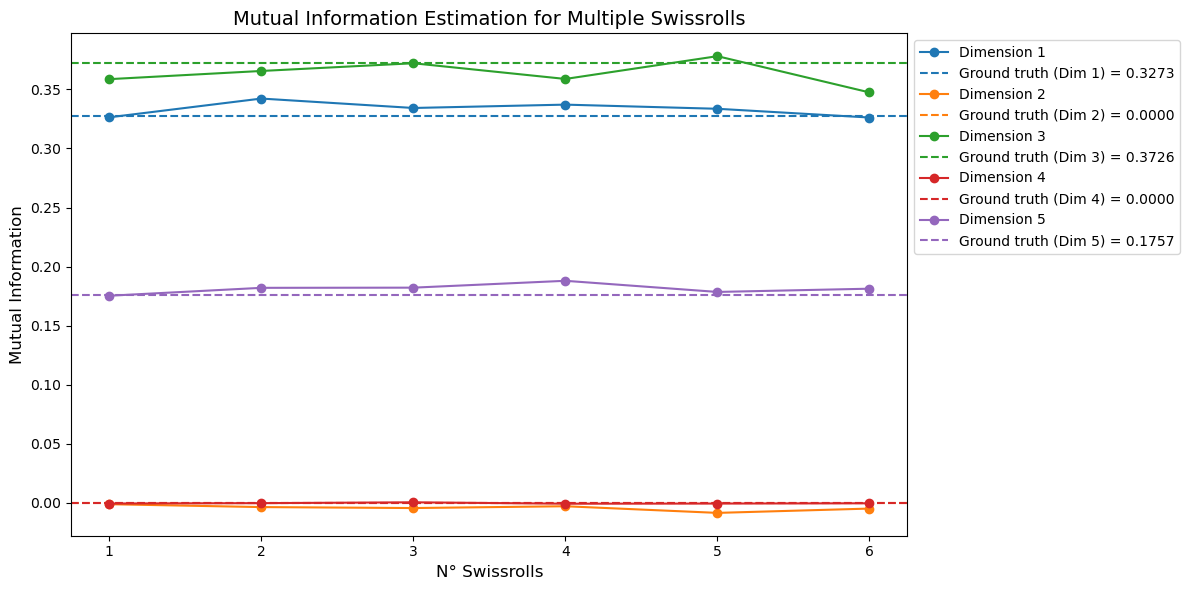

In [24]:
# Combine all MI estimates into a single array where each row contains the MI values for 1 to 6 Swissrolls
EMIS_arrays = np.array(list(zip(swiss_1_mi, swiss_2_mi, swiss_3_mi, swiss_4_mi, swiss_5_mi, swiss_6_mi))) 

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  
plt.figure(figsize=(12,6))
# Plot each dimension with its specific color
for i in range(5):
    plt.plot(range(1, len(EMIS_arrays[i]) + 1), EMIS_arrays[i], marker='o', color=colors[i], label=f'Dimension {i+1}')
    plt.axhline(y=ground_truth[i], color=colors[i], linestyle='--', label=f'Ground truth (Dim {i+1}) = {ground_truth[i]:.4f}')

plt.title("Mutual Information Estimation for Multiple Swissrolls", fontsize=14)
plt.xlabel("N° Swissrolls", fontsize=12)
plt.ylabel("Mutual Information", fontsize=12)

# Adjusting the position of the legend
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()